# Notebook 6 – Vegetation Policy

This notebook builds and evaluates a **needs-based urban trees policy**.

## Aim

Link **green infrastructure** (GVI, trees) to **temperature** and **heat mortality**, by:
- Designing a Municipio-level tree policy that increases vegetation where it is most needed.
- Converting the GVI uplift into cooling on the UrbClim T2M grid.
- Recomputing annual heat deaths (with AC) and quantifying avoided deaths.

## Inputs (from previous notebooks / config)

- City config and file paths (`configs/<slug>.yml`)
- FUA polygon and UrbClim **reference grid** (T2M daily hazard)
- Population and age structure on the ref grid for each hazard year
- **GVI** point data (0–100), **LCZ** raster, and **OSM Municipi** boundaries
- **AC coverage** maps and age-specific AC effectiveness
- Optional **SVI** (social vulnerability index) grid

## Workflow 

1. **Setup and loading**
   - Load city config, FUA, reference grid, CITY_MASK and HAZ_MASK.
   - Load daily T2M hazard and age-specific exposures for all hazard years.

2. **Vegetation and regions**
   - Load GVI points, clip to FUA, normalise to 0–100.
   - Aggregate GVI to the UrbClim grid and to OSM Municipi (region means, basic stats).
   - Build Municipi polygons (from OSM), intersect with FUA, and rasterise to the ref grid.

3. **Baseline GVI by Municipio**
   - Compute **population-weighted GVI** per Municipio (baseline exposure year, e.g. 2030).
   - Filter Municipi with too few GVI samples or manually excluded in YAML.
   - Produce descriptive and population-weighted GVI tables and maps.

4. **Needs-based trees policy (TARGET & CAP)**
   - Set **TARGET** GVI as the Q3 of pop-weighted Municipi GVI (rounded to 0.01).
   - Apply a per-Municipio **CAP** on GVI uplift (from `trees.cap_pp` in YAML).
   - Compute Municipio-level uplift `dGVI` (0–1) and map it to pixels:
     - `dGVI_points` = pixel-level change in GVI in “points” (0–100).
   - Compute citywide **ΔGVI (population-weighted)** and share of population benefiting.
   - Export the policy table (`trees_tbl`) with before/after GVI per Municipio.

5. **From ΔGVI to ΔT (cooling)**
   - Load **cooling coefficients** by month × LCZ (outer_2_mean).
   - For each pixel (built LCZ 1–10), compute monthly cooling.
   - Build a 12×H×W stack of monthly cooling (`dT_month_ref`, cooling-only ≤ 0).
   - Summarise **population-weighted ΔT** by month and annual mean.

6. **Modify the daily hazard**
   - Map the monthly ΔT to each day (by month) and build a new hazard `H_trees`.
   - Check city-mean daily cooling over the year and example maps (baseline vs trees vs ΔT).

7. **Heat impacts with AC (2030, 2040, 2050)**
   - Rebuild **age-specific impact functions** from frozen curves (NB4 output).
   - Load **AC coverage cubes** (baseline and policy) and age-specific AC effectiveness.
   - For each year, compute annual heat deaths under:
     - Baseline (current AC)
     - Trees only (current AC + tree cooling)
     - AC policy only
     - Trees + AC policy
   - Derive **avoided deaths** vs current AC, by age group and overall.
   - Export CSVs and an Excel bundle with deaths and rates per 100k.

8. **Spatial & distributional diagnostics**
   - Aggregate avoided deaths to **Municipi** (2030/40/50) + city summaries.
   - If an SVI layer is available:
     - Build **SVI quintiles** (row-based and population-weighted).
     - Compare baseline vs trees: deaths and avoided deaths per 100k by SVI quintile,
       Q5/Q1 rate ratios, and distribution of benefits.
   - Compute Municipio-level **population-weighted ΔT**:
     - July and Jun–Sep means.
     - **ITT** (include zeros: average effect for all residents in scope).
     - **ETT** (exclude zeros: effect where cooling actually occurs).

9. **Outputs for CBA & mapping**

   - Vectors:
     - `SLUG_regions.gpkg` (`regions`, `muni` layers)
     - Municipio lookup CSV (`*_muni_lut.csv`)
   - Rasters on the UrbClim grid:
     - `*_muni_on_ref.tif` (Municipi IDs)
     - `*_veg_aux_arrays.npz`:
       - `CITY_MASK`, `HAZ_MASK`
       - `muni_on_ref`, `lcz_on_ref`
       - `pop_on_ref`, age groups
       - `gvi_on_ref` (0–1), `dGVI_points` (0–100), `dT_month_ref` (12,H,W)
   - Hazards:
     - Baseline hazard (already from NB2)
     - Trees hazard `hazard_T2M_daily_trees_*.h5` + matching events CSVs
   - Tables (in `outputs/<city>/tables`):
     - GVI descriptive / baseline / pop-weighted
     - Trees policy table (`trees_tbl`)
     - ΔT (July & season, ITT/ETT)
     - Annual deaths & avoided deaths bundles for all scenarios.

> **Note:** The **tree allocation is designed once** using the baseline exposure year (e.g. 2030),
> but **impacts are always computed with the correct hazard, population, and AC coverage
> for each year** (2030/2040/2050).

In [1]:
import os
os.environ["CITY"] = "genova"   # pick the city here

In [2]:
# generic bootstrap 
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# choose city here
SLUG = globals().get("SLUG", os.environ.get("CITY", "rome")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: genova  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim


In [3]:
# city config + file paths from YAML 
cfg = C.get("cfg", {})                      # full YAML for the selected city
SLUG = cfg.get("slug", SLUG).lower()        
CITY = cfg.get("city_name", CITY)

paths    = cfg.get("files", {})             # {gvi_csv, lcz_candidates, cooling_coeffs_csv, ...}
osm_cfg  = cfg.get("osm", {})               # OSM settings used later in NB5
trees_cfg = cfg.get("trees", {})            # TARGET/CAP for NB5
urbclim   = cfg.get("urbclim", {})          # UrbClim folder/settings for NB5

lcz_candidates = [P(p) for p in paths.get("lcz_candidates", [])]
gvi_path = P(paths.get("gvi_csv", ""))

# FUA geopackage written in NB2 
fua_gpkg = Path(paths.get("fua_gpkg", f"{OUT}/{SLUG}_fua.gpkg"))

cool_csv = P(paths.get("cooling_coeffs_csv", ""))

# checks
print("SLUG/CITY:", SLUG, CITY)
print("GVI CSV:  ", gvi_path)
print("LCZ cand: ", [str(p) for p in lcz_candidates])
print("FUA GPKG: ", fua_gpkg)
print("Cooling CSV:", cool_csv)

SLUG/CITY: genova Genova
GVI CSV:   /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/gviGenova/gvi_Genova.csv
LCZ cand:  ['/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/LCZ/lcz_filter_v3.tif', '/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/LCZ/lcz_v3.tif']
FUA GPKG:  /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/genova_fua.gpkg
Cooling CSV: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/CoolingEff/outer_2_wbgt_max.csv


**Loading what we need from previous notebooks**

In [4]:
from pathlib import Path
import json, numpy as np, geopandas as gpd, rasterio as rio
from climada.hazard import Hazard
from climada.entity.exposures import Exposures
import pandas as pd

def _days_in_year(y):
    return 366 if (y % 4 == 0 and (y % 100 != 0 or y % 400 == 0)) else 365

def reattach_daily_dates(INT, SLUG, H):
    csv = Path(INT) / f"hazard_T2M_daily_events_{SLUG}.csv"
    df = pd.read_csv(csv).sort_values("row").reset_index(drop=True)

    n = H.intensity.shape[0]
    assert len(df) == n, f"Events CSV rows ({len(df)}) != hazard rows ({n})."

    H.event_id   = df["event_id"].to_numpy(int)
    H.date       = pd.to_datetime(df["date"]).to_numpy("datetime64[ns]")
    H.event_name = np.array([f"T2M_{d.date()}" for d in pd.to_datetime(df["date"])], dtype=object)

    yrs = pd.to_datetime(df["date"]).dt.year.to_numpy(int)
    H.frequency      = np.array([1.0/_days_in_year(y) for y in yrs], dtype=float)
    H.frequency_unit = "1/year"
    return H

tmpl_path = INT / "template_ref.tif"
mask_tif  = INT / "city_mask.tif"
fua_gp    = OUT / f"{SLUG}_fua.gpkg"

age_npz = INT / f"age_on_ref_{SLUG}.npz"
if not age_npz.exists(): age_npz = INT / "age_on_ref.npz"

pop_npz = INT / f"pop_on_ref_{SLUG}.npz"
if not pop_npz.exists(): pop_npz = INT / "pop_on_ref.npz"

# Reference grid + masks 
with rio.open(tmpl_path) as src:
    ref_meta = src.meta.copy()
    HGT, WDT = ref_meta["height"], ref_meta["width"]

with rio.open(mask_tif) as src:
    CITY_MASK = src.read(1).astype(bool)

# Arrays on ref grid
agez = np.load(age_npz)
age_on_ref = {"<15": agez["lt15"], "15-64": agez["a15_64"], "65+": agez["g65"]}
pop_on_ref = np.load(pop_npz)["pop"]

# FUA
if not fua_gp.exists():
    raise FileNotFoundError(f"Missing FUA GeoPackage: {fua_gp} — re-run Notebook 2 for {CITY}.")
fua = gpd.read_file(fua_gp, layer="fua")
fua_4326 = fua.to_crs("EPSG:4326")

# Footprint on reference grid
ref_data = np.where(CITY_MASK, 0.0, np.nan)
HAZ_MASK = np.isfinite(ref_data)

print("ref grid:", (HGT, WDT), "| CRS:", ref_meta["crs"])
print("CITY_MASK true pixels:", int(CITY_MASK.sum()))

# loading daily T2M hazard + exposure 
haz_path = INT / f"hazard_T2M_daily_{SLUG}.h5"
exp_path = INT / f"exposure_people_{SLUG}.h5"
H   = Hazard.from_hdf5(haz_path)
exp = Exposures.from_hdf5(exp_path)

# restoring daily metadata and set types/units
H = reattach_daily_dates(INT, SLUG, H)
H.haz_type = "T2M"
H.units    = "degC (daily mean)"

# Hazard years actually present in H
dates_h = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))
YEARS_H = np.sort(dates_h.dt.year.unique()).astype(int).tolist()
print("Hazard years in H:", YEARS_H)

epsg = getattr(ref_meta["crs"], "to_epsg", lambda: None)()
if epsg != 3035:
    print(f"[warn] ref grid EPSG={epsg}; T2M NB2 saved EPSG:3035 expected.")

# Hazard grid size vs template
n_ref = HGT * WDT
try:
    n_ctd = len(H.centroids.lat)  # works if centroids exist
    if n_ctd != n_ref:
        print(f"[warn] Hazard centroids ({n_ctd}) ≠ ref cells ({n_ref}). Check template_ref.tif.")
except Exception:
    pass 

# Exposure population should match grid mask scope
if int(np.isfinite(pop_on_ref).sum()) == 0:
    print("[warn] pop_on_ref has no finite cells; check NPZ paths and NB2 outputs.")

ref grid: (251, 251) | CRS: EPSG:3035
CITY_MASK true pixels: 26584
Hazard years in H: [2030, 2040, 2050]


In [5]:
expo_manifest_path = INT / "exposure_manifest.json"
with open(expo_manifest_path) as f:
    expo_manifest = json.load(f)

# scenario of pop 
scen_dict = expo_manifest.get("scenarios", {})

# priority: explicit scenario.code in cfg 
scenario_cfg = (cfg or {}).get("scenario", {}) or {}
SCEN_CODE = scenario_cfg.get("code")

# exp_scenario from YAML 
if not SCEN_CODE:
    SCEN_CODE = cfg.get("exp_scenario")

# deriving from AC SSP
if (not SCEN_CODE or SCEN_CODE not in scen_dict):
    ac_cfg = cfg.get("ac", {})
    ssp = ac_cfg.get("ssp", None)
    if ssp is not None:
        for cand in (f"SSP{ssp}", f"ssp{ssp}", f"ssp{ssp}".lower(), f"SSP{ssp}".upper()):
            if cand in scen_dict:
                SCEN_CODE = cand
                break

# final fallback: first scenario in manifest
if not SCEN_CODE or SCEN_CODE not in scen_dict:
    SCEN_CODE = sorted(scen_dict.keys())[0]

print(f"Using exposure scenario: {SCEN_CODE}")
scen_rec = scen_dict[SCEN_CODE]

age_on_ref_by_year = {}
pop_on_ref_by_year = {}

for y in YEARS_H:
    rec_y = scen_rec.get(str(y))
    if rec_y is None:
        raise KeyError(
            f"No exposure entry for scenario {SCEN_CODE}, year {y} "
            f"in exposure_manifest.json"
        )

    ages_npz = np.load(rec_y["age_npz"])
    pop_npz  = np.load(rec_y["pop_npz"])

    age_on_ref_by_year[int(y)] = {
        "<15":   ages_npz["lt15"].astype("float32"),
        "15-64": ages_npz["a15_64"].astype("float32"),
        "65+":   ages_npz["g65"].astype("float32"),
    }
    pop_on_ref_by_year[int(y)] = pop_npz["pop"].astype("float32")

    # shape consistency
    for grp in ["<15", "15-64", "65+"]:
        assert age_on_ref_by_year[y][grp].shape == CITY_MASK.shape
    assert pop_on_ref_by_year[y].shape == CITY_MASK.shape

# keeping a baseline exposure for all the “design / descriptive” parts (GVI, policy design)
BASE_EXPO_YEAR = min(YEARS_H)
age_on_ref_base = age_on_ref_by_year[BASE_EXPO_YEAR]
pop_on_ref_base = pop_on_ref_by_year[BASE_EXPO_YEAR]

# for backwards compatibility
age_on_ref = age_on_ref_base
pop_on_ref = pop_on_ref_base

print(f"age_on_ref / pop_on_ref now refer to baseline year {BASE_EXPO_YEAR} "
      f"for policy design & GVI weighting.")

Using exposure scenario: SSP2
age_on_ref / pop_on_ref now refer to baseline year 2030 for policy design & GVI weighting.


In [6]:
def pop_for_year(y: int):
    """
    Return population grid for year y on the ref grid.
    Falls back to baseline exposure year if y not present.
    """
    y = int(y)
    if y in pop_on_ref_by_year:
        return pop_on_ref_by_year[y]
    return pop_on_ref_base

In [7]:
import numpy as np
import rasterio as rio
from rasterio.enums import Resampling
from rasterio.vrt import WarpedVRT
from rasterio import features
from scipy import ndimage as ndi

HAZ_MASK = CITY_MASK

# LCZ path from Drive
p_LCZ = P("LCZ")
lcz_candidates = [p_LCZ / "lcz_filter_v3.tif", p_LCZ / "lcz_v3.tif"]
lcz_path = next((p for p in lcz_candidates if p.exists()), None)
if lcz_path is None:
    raise FileNotFoundError(
        f"No LCZ raster found under {p_LCZ}. Expected one of: {', '.join(map(str, lcz_candidates))}"
    )
print("Using LCZ:", lcz_path.name)

# Reproject LCZ to the T2M ref grid 
def lcz_to_ref_stream(path, ref_meta):
    with rio.open(path) as src:
        src_nod = src.nodata if src.nodata is not None else 0  # LCZ uses 0 as nodata
        vrt_opts = dict(
            crs=ref_meta["crs"],
            transform=ref_meta["transform"],
            width=ref_meta["width"],
            height=ref_meta["height"],
            resampling=Resampling.nearest,
            src_nodata=src_nod,
            nodata=np.nan,   # output NaN where LCZ is nodata
        )
        with WarpedVRT(src, **vrt_opts) as vrt:
            return vrt.read(1, out_dtype="float32")

lcz_reproj = lcz_to_ref_stream(lcz_path, ref_meta)

# masking to FUA on the reference grid (na outside city)
lcz_on_ref = np.where(HAZ_MASK, lcz_reproj, np.nan)

# filling LCZ holes only inside the hazard footprint and keeping 0 strictly outside hazard
work = np.where(HAZ_MASK, lcz_on_ref, np.nan)          # ignore outside-hazard during fill
missing_inside = np.isnan(work) & HAZ_MASK

if missing_inside.any():
    valid = (~np.isnan(work)) & HAZ_MASK
    _, (iy, ix) = ndi.distance_transform_edt(~valid, return_indices=True)
    work[missing_inside] = work[iy[missing_inside], ix[missing_inside]]

# Final LCZ on ref grid: integers inside hazard, 0 outside hazard
lcz_on_ref = np.where(HAZ_MASK, work, 0).astype("int16")
assert ((lcz_on_ref > 0) | (~HAZ_MASK)).all(), "Found LCZ<=0 inside hazard — check inputs."

Using LCZ: lcz_filter_v3.tif


In [8]:
import pandas as pd
import numpy as np

ev_path = INT / f"hazard_T2M_daily_events_{SLUG}.csv"
ev = pd.read_csv(ev_path, parse_dates=["date"])
assert len(ev) == H.intensity.shape[0], "events csv length must match hazard rows"

H.date = ev["date"].to_numpy("datetime64[ns]")

dates = pd.to_datetime(H.date)
for y in [2030, 2040, 2050]:
    print(y, int((dates.year == y).sum()))

2030 365
2040 366
2050 365


In [9]:
from cityheat.vulnerability_layer import load_vulnerability

# loading SVI 
vuln = load_vulnerability(INT, SLUG)
svi_grid = vuln["svi"]

HAS_VULN = np.isfinite(svi_grid).any()
print("HAS_VULN:", HAS_VULN)

HAS_VULN: True


## GVI

In [10]:
import math
import pandas as pd
import numpy as np
import geopandas as gpd
import rasterio as rio
from rasterio.transform import rowcol

files_cfg = (cfg or {}).get("files", {})
gvi_rel = files_cfg.get("gvi_csv")
if not gvi_rel:
    raise KeyError("Missing 'files.gvi_csv' in YAML config.")
gvi_path = P(gvi_rel)

# reading CSV as WGS84 points, then reproject once to the T2M ref CRS (EPSG:3035) 
gvi_df = pd.read_csv(gvi_path)

# ensuring x,y,gvi columns 
colmap = {c.lower(): c for c in gvi_df.columns}
need = {"x", "y", "gvi"}
missing = need - set(colmap)
if missing:
    raise ValueError(f"GVI CSV must have columns {need}, got {list(gvi_df.columns)}")

gvi_gdf = gpd.GeoDataFrame(
    gvi_df.rename(columns={
        colmap["x"]: "x", colmap["y"]: "y", colmap["gvi"]: "gvi"
    }),
    geometry=gpd.points_from_xy(gvi_df[colmap["x"]], gvi_df[colmap["y"]]),
    crs="EPSG:4326"
).to_crs(ref_meta["crs"])

# keeping points inside FUA (use the same FUA used in NB2, reprojected to ref CRS)
fua_ref = fua.to_crs(ref_meta["crs"])
gvi_gdf = gvi_gdf.sjoin(fua_ref[["geometry"]], predicate="within", how="inner").drop(columns="index_right")

# scale check, keep 0–100
gvi_min, gvi_med, gvi_max = float(gvi_gdf["gvi"].min()), float(gvi_gdf["gvi"].median()), float(gvi_gdf["gvi"].max())
if gvi_max <= 1.2:  # looks like 0–1
    gvi_gdf["gvi"] = gvi_gdf["gvi"] * 100.0
    print("Detected 0–1 GVI; converted to 0–100.")
else:
    print("GVI appears already on 0–100 scale.")

print(f"GVI stats (after FUA filter): min={gvi_gdf['gvi'].min():.2f} "
      f"med={gvi_gdf['gvi'].median():.2f} max={gvi_gdf['gvi'].max():.2f} | points kept={len(gvi_gdf)}")

GVI appears already on 0–100 scale.
GVI stats (after FUA filter): min=2.30 med=12.08 max=37.56 | points kept=606


In [11]:
display(gvi_gdf.head())
print(f"  shape: {gvi_gdf.shape}")

,city,x,y,lcz_filter_v3,gvi,geometry
0,Genoa,8.737716,44.424548,6.0,5.356411,POINT (4220281.7 2369055.108)
1,Genoa,8.738611,44.424972,6.0,9.910346,POINT (4220353.798 2369100.868)
2,Genoa,8.742271,44.430237,6.0,6.846162,POINT (4220655.097 2369679.833)
3,Genoa,8.743505,44.428502,6.0,4.581391,POINT (4220750.473 2369485.736)
4,Genoa,8.743953,44.434002,11.0,23.749352,POINT (4220795.918 2370094.963)


  shape: (606, 6)


In [12]:
# aggregating points to the T2M ref grid (mean GVI per cell)
HGT, WDT = ref_meta["height"], ref_meta["width"]
transform = ref_meta["transform"]

# mapping each point to (row, col)
rows, cols = rowcol(transform,
                    gvi_gdf.geometry.x.values,
                    gvi_gdf.geometry.y.values,
                    op=math.floor)

# keeping only points that fall inside the raster bounds and CITY_MASK
in_bounds = (rows >= 0) & (rows < HGT) & (cols >= 0) & (cols < WDT)
rows, cols = rows[in_bounds], cols[in_bounds]
vals = gvi_gdf["gvi"].values[in_bounds]

# restricting further to CITY_MASK True
cmask = CITY_MASK[rows, cols]
rows, cols, vals = rows[cmask], cols[cmask], vals[cmask]

# bin by cell: mean = sum / count
gvi_sum = np.zeros((HGT, WDT), dtype=np.float64)
gvi_cnt = np.zeros((HGT, WDT), dtype=np.int32)
np.add.at(gvi_sum, (rows, cols), vals)
np.add.at(gvi_cnt, (rows, cols), 1)

with np.errstate(divide="ignore", invalid="ignore"):
    gvi_mean = gvi_sum / gvi_cnt
gvi_on_ref = np.where(CITY_MASK, gvi_mean, np.nan).astype("float32")

# check
nz = int(np.sum((gvi_cnt > 0) & CITY_MASK))
print(f"GVI cells populated: {nz} / {int(CITY_MASK.sum())} within CITY_MASK.")

GVI cells populated: 565 / 26584 within CITY_MASK.


CRS check (should both be EPSG:3035 here):
  gvi_gdf.crs = PROJCS["ETRS89-extended / LAEA Europe",GEOGCS["ETRS89",DATUM["European_Terrestrial_Reference_System_1989",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6258"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4258"]],PROJECTION["Lambert_Azimuthal_Equal_Area"],PARAMETER["latitude_of_center",52],PARAMETER["longitude_of_center",10],PARAMETER["false_easting",4321000],PARAMETER["false_northing",3210000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Northing",NORTH],AXIS["Easting",EAST],AUTHORITY["EPSG","3035"]]
  fua_ref.crs = PROJCS["ETRS89-extended / LAEA Europe",GEOGCS["ETRS89",DATUM["European_Terrestrial_Reference_System_1989",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6258"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG",

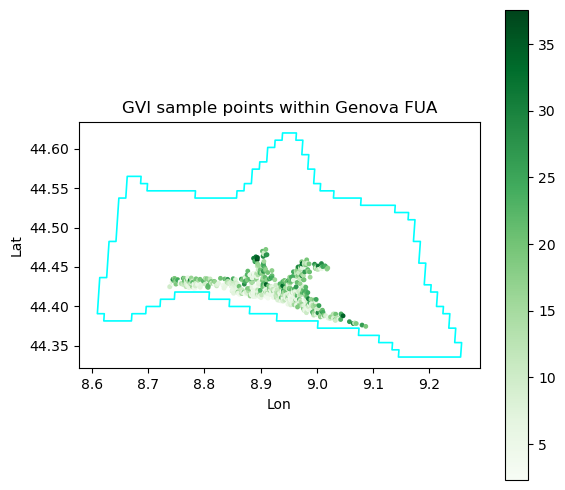

In [13]:
# Check
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("CRS check (should both be EPSG:3035 here):")
print("  gvi_gdf.crs =", gvi_gdf.crs)
print("  fua_ref.crs =", fua_ref.crs)

# Counting points before/after the FUA clip
n_raw  = len(pd.read_csv(gvi_path))   # path from YAML
n_keep = len(gvi_gdf)
pct    = 100.0 * n_keep / max(n_raw, 1)
print(f"Points kept inside FUA: {n_keep} / {n_raw}  ({pct:.1f}%)")

# GVI stats after FUA filter (note: earlier we already normalized to 0–100 if needed)
na_gvi = int(gvi_gdf["gvi"].isna().sum())
gvi_min, gvi_p50, gvi_max = float(gvi_gdf["gvi"].min()), float(gvi_gdf["gvi"].median()), float(gvi_gdf["gvi"].max())
print(f"GVI (post-filter): min={gvi_min:.2f}, median={gvi_p50:.2f}, max={gvi_max:.2f}, NaNs={na_gvi}")

if gvi_max <= 100 + 1e-6:
    print("GVI now appears on a 0–100 scale (expected).")
else:
    print("WARNING: GVI scale looks unusual (>100). Check upstream conversion.")

# approx duplicates check in lon/lat
gvi_ll = gvi_gdf.to_crs("EPSG:4326").copy()
dups = (
    gvi_ll
    .assign(lon=lambda d: d.geometry.x.round(6),
            lat=lambda d: d.geometry.y.round(6))
    .duplicated(subset=["lon", "lat"])
    .sum()
)
print("Approx duplicate coords (EPSG:4326, rounded to 1e-6):", int(dups))

# map: plot in lon/lat (readable axes)
fua_4326 = fua_ref.to_crs("EPSG:4326")
ax = fua_4326.plot(edgecolor="cyan", facecolor="none", linewidth=1.2, figsize=(6, 5))
gvi_ll.plot(ax=ax, markersize=6, column="gvi", cmap="Greens", legend=True)
ax.set_title(f"GVI sample points within {CITY} FUA")
ax.set_xlabel("Lon"); ax.set_ylabel("Lat")
plt.tight_layout(); plt.show()

# If many points were dropped, suggest a boundary-inclusive join on the SAME CRS (ref grid)
if n_keep < 0.5 * n_raw:
    print("\nMany points were dropped. Try a boundary-inclusive join on the ref CRS:")
    print("gvi_gdf = gvi_gdf.sjoin(fua_ref[['geometry']], predicate='intersects', how='inner').drop(columns='index_right')")

**Building Municipi (OSM), dissolving to 15 units + “Fuori Municipi”**

OSM admin_level=10 → 9 regions. Examples: ['Bassa Val Bisagno', 'Centro Est', 'Centro Ovest', 'Levante', 'Media Val Bisagno', 'Medio Levante']
Regions ready. IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 0]
Points in outside bucket (ID=0): 7
Unmatched points: 0


,muni_id,muni_name,count,mean,median,p10,p90,gvi_mean_0_1,gvi_median_0_1,area_km2,pts_per_km2
0,0,Outside regions (FUA),7,17.973093,18.784375,10.071444,27.575442,0.179731,0.187844,618.496319,0.011318
1,1,Bassa Val Bisagno,59,11.963060,9.432865,4.146562,22.379494,0.119631,0.094329,7.937521,7.433051
2,2,Centro Est,64,10.930563,9.888310,5.073474,19.317897,0.109306,0.098883,7.723666,8.286220
3,3,Centro Ovest,47,9.244785,6.513252,3.559001,17.452752,0.092448,0.065133,7.689732,6.112047
4,4,Levante,68,15.595548,15.641773,6.420908,24.933548,0.155955,0.156418,36.566507,1.859625
5,5,Media Val Bisagno,97,17.780418,18.250509,8.655848,27.052109,0.177804,0.182505,41.803647,2.320372
6,6,Medio Levante,31,10.462763,8.494739,4.047695,19.162367,0.104628,0.084947,6.094669,5.086412
7,7,Medio Ponente,69,11.766265,9.167718,5.827215,21.450940,0.117663,0.091677,22.301023,3.094028
8,8,Ponente,95,13.134163,11.311172,4.504149,22.333830,0.131342,0.113112,77.409215,1.227244
9,9,Val Polcevera,69,17.561629,18.435132,6.142965,27.852883,0.175616,0.184351,33.168685,2.080275


Min samples (excluding outside=0): 31


Text(19.847222222222214, 0.5, 'Lat')

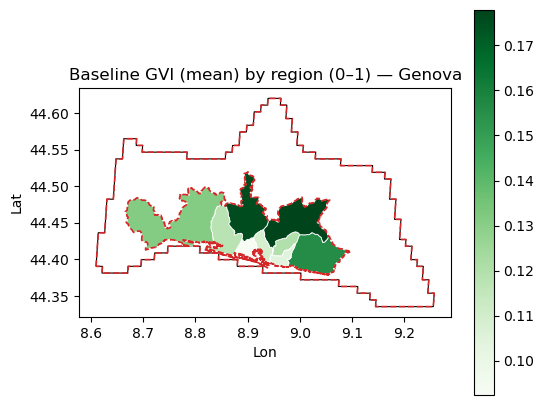

In [14]:
# City-agnostic OSM regions to `regions` (Municipi/Barrios/Districts)

import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox

# YAML
osm_cfg     = (cfg or {}).get("osm", {})
query       = osm_cfg.get("query", CITY)
levels      = [str(x) for x in osm_cfg.get("admin_levels", [10, 8, 7])]
b_tag       = osm_cfg.get("boundary_tag", "administrative")
keep_out    = bool(osm_cfg.get("keep_outside_bucket", True))
exclude_ids = set(int(i) for i in osm_cfg.get("exclude_region_ids", []))

# OSMnx settings
ox.settings.use_cache = True
ox.settings.log_console = False

# City polygon (WGS84)
city_poly = ox.geocode_to_gdf(query).to_crs("EPSG:4326").geometry.iloc[0]

# Pull boundary features, keep polygons, ensure WGS84
raw = ox.features_from_polygon(city_poly, tags={"boundary": b_tag})
raw = raw[raw.geometry.type.isin(["Polygon", "MultiPolygon"])].copy().to_crs("EPSG:4326")
for col in ("admin_level", "boundary", "name", "name:it", "short_name", "ref"):
    if col not in raw.columns:
        raw[col] = None

# picking first available admin_level from the list
picked = None
sel_level = None
for level in levels:
    cand = raw[(raw["boundary"] == b_tag) & (raw["admin_level"].astype(str) == level)]
    if not cand.empty:
        picked = cand.copy()
        sel_level = level
        break
if picked is None:
    raise RuntimeError(
        f"No OSM '{b_tag}' polygons with admin_level in {levels} for '{query}'. "
        "Adjust cfg.osm.admin_levels or cfg.osm.query."
    )

# Clip to FUA footprint (FUA already available as WGS84 in fua_4326)
picked = gpd.overlay(
    picked[["geometry", "name", "name:it", "short_name", "ref"]].reset_index(drop=True),
    fua_4326[["geometry"]],
    how="intersection"
)

# Readable names
def _pick_name(row):
    for k in ("name:it", "name", "short_name", "ref"):
        v = row.get(k)
        if isinstance(v, str) and v.strip():
            return v.strip()
    return "Region"

picked["muni_name"] = picked.apply(_pick_name, axis=1)

# One polygon per region
muni = picked.dissolve(by="muni_name", as_index=False, aggfunc="first").reset_index(drop=True)

# Stable integer IDs (Roman numerals for Rome, else sequential)
roman_map = {"I":1,"II":2,"III":3,"IV":4,"V":5,"VI":6,"VII":7,"VIII":8,
             "IX":9,"X":10,"XI":11,"XII":12,"XIII":13,"XIV":14,"XV":15}
rom = muni["muni_name"].str.extract(r'([IVXLCDM]+)\s*$', expand=False)
ids = rom.map(roman_map)

if ids.notna().all():
    muni["muni_id"] = ids.astype(int)
else:
    muni = muni.reset_index(drop=True)
    muni["muni_id"] = muni.index + 1

# optional manual exclusions
if exclude_ids:
    before = len(muni)
    muni = muni[~muni["muni_id"].isin(exclude_ids)].copy()
    muni = muni.sort_values("muni_id").reset_index(drop=True)
    print(f"Excluded IDs {sorted(exclude_ids)} → {before} → {len(muni)} regions.")

print(f"OSM admin_level={sel_level} → {len(muni)} regions. Examples:",
      sorted(muni['muni_name'].unique())[:6])

# “Outside FUA” bucket (ID 0), optional
regions_parts = [muni[["muni_id", "muni_name", "geometry"]]]
if keep_out:
    gseries = muni.geometry
    geom_union = gseries.union_all() if hasattr(gseries, "union_all") else gseries.unary_union
    muni_union = gpd.GeoDataFrame(geometry=[geom_union], crs="EPSG:4326")
    outside = gpd.overlay(fua_4326[["geometry"]], muni_union, how="difference")
    if not outside.empty:
        outside = outside.set_crs("EPSG:4326")
        outside["muni_id"] = 0
        outside["muni_name"] = "Outside regions (FUA)"
        regions_parts.append(outside[["muni_id", "muni_name", "geometry"]])

# Final layer (WGS84)
regions = pd.concat(regions_parts, ignore_index=True).set_crs("EPSG:4326")
print("Regions ready. IDs:", regions["muni_id"].tolist())

# GVI × Regions aggregation 

# IMPORTANT: reproject GVI points to WGS84 for the join (regions are EPSG:4326)
gvi_ll = gvi_gdf.to_crs("EPSG:4326")

# Spatial join: tag each GVI point with a region
gvi_in_regions = gvi_ll.sjoin(
    regions[["muni_id", "muni_name", "geometry"]],
    predicate="within",
    how="left"
).drop(columns="index_right")

# If many are unmatched, try boundary-inclusive join
n_unmatched = int(gvi_in_regions["muni_id"].isna().sum())
if n_unmatched > 0.2 * len(gvi_in_regions):
    gvi_in_regions = gvi_ll.sjoin(
        regions[["muni_id", "muni_name", "geometry"]],
        predicate="intersects",
        how="left"
    ).drop(columns="index_right")

# Diagnostics
has_outside = (regions["muni_id"] == 0).any()
n_outside   = int((gvi_in_regions["muni_id"] == 0).sum()) if has_outside else 0
n_unmatched = int(gvi_in_regions["muni_id"].isna().sum())
print(f"Points in outside bucket (ID=0): {n_outside}")
print(f"Unmatched points: {n_unmatched}")

# Aggregate by region (keep 0–100 and scaled 0–1)
reg_gvi = (gvi_in_regions
           .groupby(["muni_id", "muni_name"], as_index=False)["gvi"]
           .agg(count="count",
                mean="mean",
                median="median",
                p10=lambda s: s.quantile(0.10),
                p90=lambda s: s.quantile(0.90)))
reg_gvi["gvi_mean_0_1"]   = reg_gvi["mean"]   / 100.0
reg_gvi["gvi_median_0_1"] = reg_gvi["median"] / 100.0

# Region areas and sample density (use local metric CRS)
metric_crs = regions.estimate_utm_crs() or "EPSG:3857"
areas = regions.to_crs(metric_crs)[["muni_id", "geometry"]].copy()
areas["area_km2"] = areas.geometry.area / 1e6

reg_gvi = (reg_gvi
           .merge(areas[["muni_id", "area_km2"]], on="muni_id", how="left")
           .assign(pts_per_km2=lambda d: d["count"] / d["area_km2"])
           .sort_values(["muni_id", "muni_name"])
           .reset_index(drop=True))

display(reg_gvi)

if (reg_gvi["muni_id"] > 0).any():
    print("Min samples (excluding outside=0):",
          int(reg_gvi.loc[reg_gvi["muni_id"] > 0, "count"].min()))

# map: region means (exclude outside bucket)
muni_only = regions.loc[regions["muni_id"] > 0]
muni_gvi  = muni_only.merge(reg_gvi, on=["muni_id", "muni_name"], how="left")

ax = fua_4326.plot(edgecolor="k", facecolor="none", linewidth=0.8, figsize=(6, 5))
muni_gvi.plot(ax=ax, column="gvi_mean_0_1", cmap="Greens",
              legend=True, edgecolor="white", linewidth=0.6)
if has_outside:
    regions.loc[regions["muni_id"] == 0].plot(
        ax=ax, facecolor="none", edgecolor="tab:red", linewidth=1.2, linestyle="--"
    )
ax.set_title(f"Baseline GVI (mean) by region (0–1) — {CITY}")
ax.set_xlabel("Lon"); ax.set_ylabel("Lat")

This is only informative, a descriptive analysis, after we need to do GVI to T2M grid

In [15]:
# summary of region-level GVI (means), excluding outside bucket (muni_id == 0 if present)
has_outside = (reg_gvi["muni_id"] == 0).any()
mask = reg_gvi["muni_id"] != 0 if has_outside else reg_gvi["muni_id"].notna()

s100 = reg_gvi.loc[mask, "mean"].dropna()          # 0–100 scale
s01  = reg_gvi.loc[mask, "gvi_mean_0_1"].dropna()  # 0–1 scale

def summarize(s):
    return pd.Series({
        "min": s.min(),
        "Q1": s.quantile(0.25),
        "median": s.median(),
        "mean": s.mean(),
        "Q3": s.quantile(0.75),
        "max": s.max(),
        "sd":  s.std(ddof=1)
    })

summary_table = pd.concat([summarize(s100), summarize(s01)], axis=1)
summary_table.columns = ["GVI (0–100)", "GVI (0–1)"]
display(summary_table.round(2))

,GVI (0–100),GVI (0–1)
min,9.24,0.09
Q1,10.93,0.11
median,11.96,0.12
mean,13.16,0.13
Q3,15.60,0.16
max,17.78,0.18
sd,3.11,0.03


In [16]:
# City-agnostic filtering 
osm_cfg = (cfg or {}).get("osm", {})
MIN_SAMPLES = int(osm_cfg.get("min_samples", 10))
EXCLUDE_IDS = set(int(x) for x in osm_cfg.get("exclude_region_ids", []))

mask = (
    reg_gvi["muni_id"].notna()
    & (~reg_gvi["muni_id"].isin({0} | EXCLUDE_IDS))
    & (reg_gvi["count"] >= MIN_SAMPLES)
)

reg_gvi_ok = reg_gvi.loc[mask, ["muni_id","muni_name","gvi_mean_0_1"]].copy()
muni_ok    = muni[muni["muni_id"].isin(reg_gvi_ok["muni_id"])]

In [17]:
# Municipi and LCZ to T2M (UrbClim EPSG:3035) reference grid 

import numpy as np
import rasterio
from rasterio.mask import mask as rio_mask
from rasterio.warp import reproject
from rasterio.enums import Resampling
import geopandas as gpd
from pathlib import Path

# Helper: open any raster, clip to FUA, return float array with NaNs outside FUA
def read_and_mask_to_fua(raster_path: Path, fua_gdf: gpd.GeoDataFrame):
    with rasterio.open(raster_path) as src:
        fua_in_src = fua_gdf.to_crs(src.crs)
        geoms = [g for g in fua_in_src.geometry if g is not None]
        if not geoms:
            raise ValueError("FUA geometry is empty or invalid.")
        out, out_transform = rio_mask(src, geoms, crop=True, filled=True, nodata=np.nan)

        data = out[0].astype("float32")
        nod = src.nodata
        if nod is not None and not np.isnan(nod):
            data[data == nod] = np.nan

        meta = src.meta.copy()
        meta.update({
            "height": data.shape[0],
            "width":  data.shape[1],
            "transform": out_transform,
            "dtype": "float32"
        })
        return data, out_transform, src.crs, meta

# Reproject to the EXACT T2M ref grid, perserving na and clipping back to T2M footprint
def ensure_on_t2m_grid_nearest(src_path: Path, ref_meta, ref_data_shape, fua_gdf: gpd.GeoDataFrame, haz_mask=None):
    """Clip src raster to FUA and resample to the T2M reference grid (nearest), keeping NaNs."""
    src_data, _, _, src_meta = read_and_mask_to_fua(src_path, fua_gdf)

    same_grid = (
        (src_meta["crs"] == ref_meta["crs"]) and
        (src_meta["transform"] == ref_meta["transform"]) and
        (src_data.shape == ref_data_shape)
    )
    if same_grid:
        dst = src_data.astype("float32")
    else:
        dst = np.full(ref_data_shape, np.nan, dtype="float32")
        reproject(
            source=src_data,
            destination=dst,
            src_transform=src_meta["transform"],
            src_crs=src_meta["crs"],
            dst_transform=ref_meta["transform"],
            dst_crs=ref_meta["crs"],
            resampling=Resampling.nearest,
            src_nodata=np.nan,          # treat na as nodata 
            dst_nodata=np.nan,
        )

    # enforcing T2M hazard footprint
    if haz_mask is not None:
        dst = np.where(haz_mask, dst, np.nan).astype("float32")

    return dst, ref_meta

In [18]:
import numpy as np
from rasterio import features

# Municipi to T2M reference grid (EPSG:3035 from template_ref.tif)
muni_ref = muni.to_crs(ref_meta["crs"])

# ensuring integer IDs
muni_ref = muni_ref.copy()
muni_ref["muni_id"] = muni_ref["muni_id"].astype(int)

# rasterising IDs; 0 = no region
shapes = [(geom, int(mid)) for geom, mid in zip(muni_ref.geometry, muni_ref["muni_id"])]
muni_on_ref = features.rasterize(
    shapes=shapes,
    out_shape=(ref_meta["height"], ref_meta["width"]),
    transform=ref_meta["transform"],
    fill=0,
    dtype="int32",
)

# keeping only the T2M hazard footprint 
# inside footprint: keep IDs; outside: set to 0
if 'HAZ_MASK' in globals():
    muni_on_ref = np.where(HAZ_MASK, muni_on_ref, 0).astype("int32")

# Quick sanity
uniq = np.unique(muni_on_ref)
print(f"Rasterized Municipi IDs on T2M grid: {uniq[:10]}{'...' if len(uniq)>10 else ''}  (0 = outside)")

Rasterized Municipi IDs on T2M grid: [0 1 2 3 4 5 6 7 8 9]  (0 = outside)


In [19]:
print("muni_on_ref:", muni_on_ref.shape, "unique IDs:", np.unique(muni_on_ref).size)

muni_on_ref: (251, 251) unique IDs: 10


In [20]:
import numpy as np
from scipy import ndimage as ndi

# using HAZ_MASK 
haz_mask = np.isfinite(ref_data)

# filling only inside hazard
work = np.where(haz_mask, lcz_on_ref, np.nan)
missing_inside = np.isnan(work) & haz_mask

if missing_inside.any():
    valid = (~np.isnan(work)) & haz_mask
    _, (iy, ix) = ndi.distance_transform_edt(~valid, return_indices=True)
    work[missing_inside] = work[iy[missing_inside], ix[missing_inside]]

# check
lcz_on_ref = np.where(haz_mask, work, 0).astype("int16")
assert ((lcz_on_ref > 0) | (~haz_mask)).all(), "Still have LCZ==0 inside hazard—check inputs."
print("OK: LCZ now defined for all hazard pixels.")

OK: LCZ now defined for all hazard pixels.


**GVI to UrbClim grid (cell means; nearest fill)**

Everything on UrbClim grid. We map points to cells, average if multiple points fall in the same cell, and fill empty cells by nearest neighbor so every hazard pixel has a GVI.

In [21]:
import numpy as np
from rasterio.transform import rowcol
from scipy import ndimage as ndi

# ensuring GVI points are in the same CRS as the T2M reference grid (EPSG:3035)
if str(gvi_gdf.crs) != str(ref_meta["crs"]):
    gvi_xy = gvi_gdf.to_crs(ref_meta["crs"]).geometry
else:
    gvi_xy = gvi_gdf.geometry

# mapping each GVI point to the T2M ref grid cell
h, w = HGT, WDT
rows, cols = rowcol(ref_meta["transform"], gvi_xy.x.values, gvi_xy.y.values, op=np.floor)
rows = rows.astype(int)
cols = cols.astype(int)

# keeping only points that fall inside the raster bounds
inside = (rows >= 0) & (rows < h) & (cols >= 0) & (cols < w)
rows, cols = rows[inside], cols[inside]

# GVI to 0–1 scale, clipped to [0, 1]
vals = (gvi_gdf.loc[inside, "gvi"].to_numpy(float) / 100.0)
vals = np.clip(vals, 0.0, 1.0)

# Bin by cell: mean of samples per cell
sum_grid = np.zeros((h, w), dtype=float)
cnt_grid = np.zeros((h, w), dtype=float)
np.add.at(sum_grid, (rows, cols), vals)
np.add.at(cnt_grid, (rows, cols), 1.0)
gvi_on_ref = np.divide(sum_grid, cnt_grid, out=np.full((h, w), np.nan), where=cnt_grid > 0)

# filling missing only within the hazard footprint
missing = HAZ_MASK & ~np.isfinite(gvi_on_ref)
if missing.any():
    valid = HAZ_MASK & np.isfinite(gvi_on_ref)
    _, (iy, ix) = ndi.distance_transform_edt(~valid, return_indices=True)
    gvi_on_ref[missing] = gvi_on_ref[iy[missing], ix[missing]]

# keeping na outside the hazard footprint
gvi_on_ref[~HAZ_MASK] = np.nan

# Diagnostics
share_city = float(np.isfinite(gvi_on_ref)[CITY_MASK].mean()) if CITY_MASK.any() else np.nan
share_haz  = float(np.isfinite(gvi_on_ref)[HAZ_MASK].mean())  if HAZ_MASK.any()  else np.nan
print("gvi_on_ref built.")
print(f"  Finite share on CITY_MASK: {share_city:.3f}")
print(f"  Finite share on HAZ_MASK : {share_haz:.3f}")

gvi_on_ref built.
  Finite share on CITY_MASK: 1.000
  Finite share on HAZ_MASK : 1.000


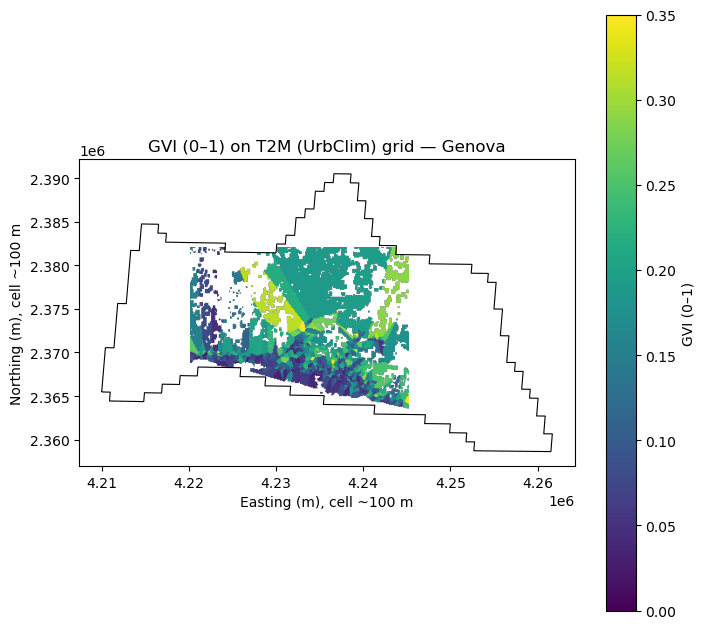

In [22]:
import matplotlib.pyplot as plt
from rasterio.plot import show as rshow

# FUA in ref CRS (EPSG:3035)
fua_ref = fua.to_crs(ref_meta["crs"])

fig, ax = plt.subplots(figsize=(7.2, 6.4))

rshow(gvi_on_ref, transform=ref_meta["transform"], ax=ax, vmin=0, vmax=0.35)
cb = plt.colorbar(ax.images[0], ax=ax); cb.set_label("GVI (0–1)")

# boundary FUA
fua_ref.boundary.plot(ax=ax, color="k", lw=0.8)

# axes labels that match EPSG:3035 meters
dx = ref_meta["transform"].a
dy = abs(ref_meta["transform"].e)
ax.set_title(f"GVI (0–1) on T2M (UrbClim) grid — {CITY}")
ax.set_xlabel(f"Easting (m), cell ~{dx:.0f} m")
ax.set_ylabel(f"Northing (m), cell ~{dy:.0f} m")
ax.set_aspect("equal", "box")
plt.tight_layout(); plt.show()

<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
Here we just put the GVI on the UrbClim grid. The map shows the pixel values (cell means of points that fall in the cell) with nearest neighbor fill for gaps. 
The plot before was the average of all points inside a whole municipio (before clipping GVI to WBGT grid).
</blockquote>

**Municipi & LCZ on T2M grid**

In [23]:
# getting rid of Municipi with too small samples points
# City-agnostic filter: dropping regions with too few GVI points (and the outside bucket if present)
osm_cfg = (cfg or {}).get("osm", {})
MIN_SAMPLES = int(osm_cfg.get("min_samples", 10))

has_outside = (reg_gvi["muni_id"] == 0).any()
drop_ids = set()

# Outside bucket 
if has_outside:
    drop_ids.add(0)

# Regions with < MIN_SAMPLES samples
weak_ids = set(reg_gvi.loc[reg_gvi["count"] < MIN_SAMPLES, "muni_id"].astype(int))
drop_ids |= weak_ids

keep_mask = (
    reg_gvi["muni_id"].notna()
    & (~reg_gvi["muni_id"].astype(int).isin(drop_ids))
)

reg_gvi_ok = reg_gvi.loc[keep_mask, ["muni_id", "muni_name", "gvi_mean_0_1"]].copy()
muni_ok    = regions.loc[regions["muni_id"].isin(reg_gvi_ok["muni_id"])].copy()

print(f"Dropped for < {MIN_SAMPLES} samples:", sorted(weak_ids))
if has_outside:
    print("Dropped outside bucket (ID=0).")
print("Kept IDs:", sorted(reg_gvi_ok["muni_id"].astype(int).unique().tolist()))

Dropped for < 10 samples: [0]
Dropped outside bucket (ID=0).
Kept IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9]


In [24]:
# rasterize ALL Municipi, then defining POLICY scope 

import rasterio as rio
from rasterio.enums import Resampling
from rasterio.features import rasterize
from rasterio.vrt import WarpedVRT
from scipy import ndimage as ndi
import numpy as np
from pathlib import Path

# rasterising ALL Municipi to the T2M ref grid 
muni_ref_all = muni.to_crs(ref_meta["crs"]).copy()
muni_ref_all["muni_id"] = muni_ref_all["muni_id"].astype(int)

shapes_all = [(geom, int(mid)) for geom, mid in zip(muni_ref_all.geometry, muni_ref_all["muni_id"])]

muni_on_ref = rasterize(
    shapes=shapes_all,
    out_shape=(HGT, WDT),
    transform=ref_meta["transform"],
    fill=0,            # 0 = outside any Municipio
    dtype="int32"
)
# keeping only the hazard footprint
muni_on_ref = np.where(HAZ_MASK, muni_on_ref, 0).astype("int32")

# defining kept IDs for the trees policy and the POLICY mask
keep_ids = reg_gvi_ok["muni_id"].astype(int).tolist()   # these exclude Municipio 10
POLICY   = CITY_MASK & np.isin(muni_on_ref, keep_ids)
MUNI_PIX = POLICY                                       # for policy 
WEIGHTS  = np.where(POLICY, pop_on_ref, 0.0)            # weights for later steps

# LCZ to ref grid 
lcz_candidates = [P("LCZ") / "lcz_filter_v3.tif", P("LCZ") / "lcz_v3.tif"]
lcz_path = next((p for p in lcz_candidates if Path(p).exists()), None)
assert lcz_path is not None, f"No LCZ raster found. Tried: {', '.join(map(str, lcz_candidates))}"

def lcz_to_ref_stream(path, ref_meta):
    with rio.open(path) as src:
        src_nod = src.nodata if src.nodata is not None else 0  # LCZ uses 0 as nodata
        vrt_opts = dict(
            crs=ref_meta["crs"],
            transform=ref_meta["transform"],
            width=ref_meta["width"],
            height=ref_meta["height"],
            resampling=Resampling.nearest,
            src_nodata=src_nod,
            nodata=np.nan,  # output na where LCZ is nodata
        )
        with WarpedVRT(src, **vrt_opts) as vrt:
            return vrt.read(1, out_dtype="float32")

# reprojecting + mask to hazard footprint (na outside)
lcz_reproj = lcz_to_ref_stream(lcz_path, ref_meta)
haz_mask = HAZ_MASK  # uniform: same footprint as the hazard/ref grid
lcz_on_ref = np.where(haz_mask, lcz_reproj, np.nan)

# filling LCZ holes only inside hazard; set exact 0 strictly outside hazard
work = np.where(haz_mask, lcz_on_ref, np.nan)
missing_inside = np.isnan(work) & haz_mask
if missing_inside.any():
    valid = (~np.isnan(work)) & haz_mask
    _, (iy, ix) = ndi.distance_transform_edt(~valid, return_indices=True)
    work[missing_inside] = work[iy[missing_inside], ix[missing_inside]]

lcz_on_ref = np.where(haz_mask, work, 0).astype("int16")
bad_inside = ((lcz_on_ref <= 0) & haz_mask).sum()
assert bad_inside == 0, f"Still have {bad_inside} LCZ<=0 pixels inside hazard—check inputs."

**Municipio-level GVI (population-weighted)**

Average where people live, not just area

In [25]:
import numpy as np
import pandas as pd

def wmean(x, w):
    m = np.isfinite(x) & np.isfinite(w) & (w > 0)
    return np.average(x[m], weights=w[m]) if m.any() else np.nan

# Vector layer defining kept regions 
M = muni_ok if 'muni_ok' in globals() else (muni if 'muni' in globals() else regions)
M = M.copy()
M["muni_id"] = M["muni_id"].astype(int)

# Valid IDs: exclude 0 and duplicates
valid_ids = np.array(sorted(set(M["muni_id"].tolist()) - {0}), dtype=int)
id_to_pos = {mid: i for i, mid in enumerate(valid_ids)}

# arrays must be on the same ref grid
assert gvi_on_ref.shape == pop_on_ref.shape == muni_on_ref.shape == (HGT, WDT)

# Pixel mask inside the hazard footprint, with data and kept Municipi
mask = (
    HAZ_MASK
    & np.isfinite(gvi_on_ref)
    & np.isfinite(pop_on_ref)
    & np.isin(muni_on_ref, valid_ids)
)

x   = gvi_on_ref[mask].astype(float)     # GVI on 0–1
w   = pop_on_ref[mask].astype(float)     # population weights
ids = muni_on_ref[mask].astype(int)

# mapping raw IDs to compact 0..K-1 bins
pos = np.fromiter((id_to_pos[i] for i in ids), count=ids.size, dtype=int)
K   = len(valid_ids)

den = np.bincount(pos, weights=w,    minlength=K)
num = np.bincount(pos, weights=w*x,  minlength=K)
gvi_pw = np.divide(num, den, out=np.full(K, np.nan), where=den > 0)

reg_gvi_grid = (
    pd.DataFrame({"muni_id": valid_ids, "gvi_mean_0_1_popw": gvi_pw})
      .merge(M[["muni_id", "muni_name"]].drop_duplicates(), on="muni_id", how="right")
      .sort_values("muni_id")
      .reset_index(drop=True)
)

display(reg_gvi_grid.head())

,muni_id,gvi_mean_0_1_popw,muni_name
0,1,0.099696,Bassa Val Bisagno
1,2,0.098594,Centro Est
2,3,0.088139,Centro Ovest
3,4,0.147854,Levante
4,5,0.174367,Media Val Bisagno


In [26]:
# City-agnostic summary of population-weighted GVI (exclude any regions not kept in M)
M = muni_ok if 'muni_ok' in globals() else (muni if 'muni' in globals() else regions)

keep_ids = set(M["muni_id"].astype(int).unique())
mask = reg_gvi_grid["muni_id"].isin(keep_ids)

s = reg_gvi_grid.loc[mask, "gvi_mean_0_1_popw"].dropna()

summary = pd.Series({
    "min":    s.min(),
    "Q1":     s.quantile(0.25),
    "median": s.median(),
    "mean":   s.mean(),
    "Q3":     s.quantile(0.75),
    "max":    s.max(),
    "sd":     s.std(ddof=1)
}).round(3)

display(pd.DataFrame(summary, columns=["GVI pop-weighted (0–1)"]))

,GVI pop-weighted (0–1)
min,0.088
Q1,0.099
median,0.103
mean,0.122
Q3,0.148
max,0.174
sd,0.034


In [27]:
# City-agnostic coverage + keep list + baseline table for policy
import numpy as np
import pandas as pd
import geopandas as gpd

# consistent CRS for the point-in-polygon join 
# regions is EPSG:4326; make a lon/lat view of GVI points (like before)
gvi_ll = gvi_gdf.to_crs("EPSG:4326")

# Spatial join (point -> region). 
gvi_in_regions = gvi_ll.sjoin(
    gpd.GeoDataFrame(regions[["muni_id","muni_name","geometry"]],
                     geometry="geometry", crs="EPSG:4326"),
    predicate="within", how="left"
)

# Point counts per region
pt_counts = (gvi_in_regions.groupby("muni_id", as_index=False)["gvi"]
             .size()
             .rename(columns={"size": "count"}))

# Areas in km2 (completely optional)
metric_crs = regions.estimate_utm_crs() or "EPSG:3857"
areas = regions.to_crs(metric_crs)[["muni_id", "geometry"]].copy()
areas["area_km2"] = areas.geometry.area / 1e6

# Merge counts + areas into the pop-weighted GVI table from the grid step
coverage = (reg_gvi_grid
            .merge(pt_counts, on="muni_id", how="left")
            .merge(areas[["muni_id", "area_km2"]], on="muni_id", how="left"))

coverage["count"] = coverage["count"].fillna(0).astype(int)
# avoid divide-by-zero/infinite densities
coverage["pts_per_km2"] = np.where(coverage["area_km2"] > 0,
                                   coverage["count"] / coverage["area_km2"],
                                   np.nan)

# applying YAML-driven filters (no hardcoded IDs) 
osm_cfg      = (cfg or {}).get("osm", {})
MIN_SAMPLES  = int(osm_cfg.get("min_samples", 10))
EXCLUDE_IDS  = set(int(x) for x in osm_cfg.get("exclude_region_ids", []))

drop_ids = set()
if (coverage["muni_id"] == 0).any():
    drop_ids.add(0)

low_sample_ids = set(coverage.loc[coverage["count"] < MIN_SAMPLES, "muni_id"].astype(int))
drop_ids |= low_sample_ids | EXCLUDE_IDS

keep_mask = ~coverage["muni_id"].astype(int).isin(drop_ids)
keep_ids  = set(coverage.loc[keep_mask, "muni_id"].astype(int))

muni_ok = regions.loc[regions["muni_id"].astype(int).isin(keep_ids)].copy()

# final baseline table for policy (population-weighted GVI)
reg_gvi_ok = (coverage.loc[coverage["muni_id"].astype(int).isin(keep_ids),
                           ["muni_id", "muni_name", "gvi_mean_0_1_popw", "count", "pts_per_km2"]]
                      .rename(columns={"gvi_mean_0_1_popw": "gvi_mean_0_1"})
                      .sort_values("muni_id")
                      .reset_index(drop=True))
display(reg_gvi_ok)

,muni_id,muni_name,gvi_mean_0_1,count,pts_per_km2
0,1,Bassa Val Bisagno,0.099696,59,7.433051
1,2,Centro Est,0.098594,64,8.286220
2,3,Centro Ovest,0.088139,47,6.112047
3,4,Levante,0.147854,68,1.859625
4,5,Media Val Bisagno,0.174367,97,2.320372
5,6,Medio Levante,0.097808,31,5.086412
6,7,Medio Ponente,0.103073,69,3.094028
7,8,Ponente,0.115508,95,1.227244
8,9,Val Polcevera,0.174166,69,2.080275


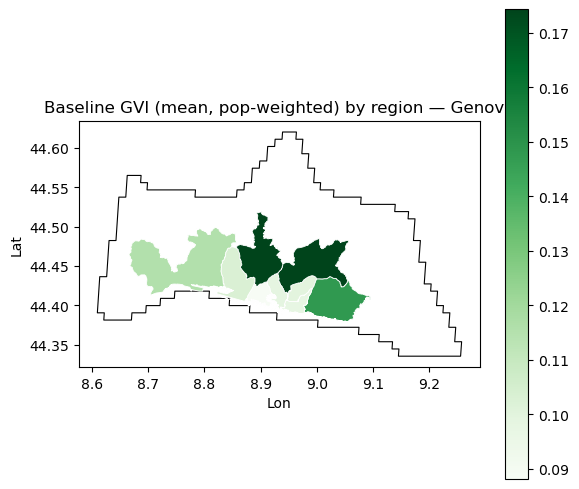

In [28]:
# Map: baseline GVI (mean, pop-weighted) by kept regions — T2M ref grid

# ensuring geometry is in EPSG:4326 for readable axes
muni_map = (muni_ok.to_crs("EPSG:4326")
            .merge(reg_gvi_ok[["muni_id","gvi_mean_0_1"]], on="muni_id", how="left"))

# Plot
ax = fua_4326.plot(edgecolor="k", facecolor="none", linewidth=0.8, figsize=(6,5))

muni_map.plot(
    ax=ax,
    column="gvi_mean_0_1",
    cmap="Greens",
    legend=True,
    edgecolor="white", linewidth=0.6,
    missing_kwds=dict(color="lightgray", edgecolor="none", label="No data")
)

ax.set_title(f"Baseline GVI (mean, pop-weighted) by region — {CITY}")
ax.set_xlabel("Lon"); ax.set_ylabel("Lat")
plt.tight_layout(); plt.show()

## Needs-based tree policy (TARGET & CAP)

<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
Citywide ΔGVI (pop-weighted over kept regions) is a population-weighted citywide mean of the policy uplift, computed over pixels that lie inside any Municipio and have people. We averaged the per-pixel change in GVI using population in each pixel as the weight. Weights = pop_on_ref, scope = MUNI_PIX (the intersection of Municipi and city footprint, Statistic = sum(change in GVI * pop)/sum(pop). It reflects the change in GVI experienced by the average resident. It's on the 0-1 scale ie *100 on the 1-100 GVI index.
</blockquote>

In [29]:
import numpy as np
import pandas as pd

# helper 
def round_up(x, step=0.01):
    return float(np.ceil((x + 1e-12) / step) * step)

# kept IDs 
M = muni_ok if 'muni_ok' in globals() else (muni if 'muni' in globals() else regions)
keep_ids = set(M["muni_id"].astype(int).unique())

# series of pop-weighted baselines over kept regions
s = reg_gvi_grid.loc[reg_gvi_grid["muni_id"].astype(int).isin(keep_ids),
                     "gvi_mean_0_1_popw"].dropna()

if s.empty:
    raise RuntimeError("No valid GVI baselines for kept regions. Check earlier steps.")

# target = ceil(Q3) to nearest 0.01 (bounded to [0,1])
q3_raw = float(s.quantile(0.75))
TARGET = float(np.clip(round_up(q3_raw, 0.01), 0.0, 1.0))

# CAP from YAML, to [0,1]
trees_cfg = (cfg or {}).get("trees", {})
CAP = float(np.clip(trees_cfg.get("cap_pp", 0.12), 0.0, 1.0))

print(f"[Target] Q3(raw)={q3_raw:.3f} → TARGET={TARGET:.2f} | CAP={CAP:.2f}")

# baselines by kept region (already pop-weighted, 0–1)
gvi0_by_muni = {int(r.muni_id): float(r.gvi_mean_0_1) for r in reg_gvi_ok.itertuples()}
dGVI_needs   = {mid: float(np.clip(TARGET - g0, 0.0, CAP)) for mid, g0 in gvi0_by_muni.items()}

# LUT sized from the raster label space to avoid index errors
lut_size = int(np.nanmax(muni_on_ref)) + 1
lut = np.full(lut_size, np.nan, dtype=float)
for mid, d in dGVI_needs.items():
    if mid < lut_size:
        lut[mid] = d  # unkept or absent IDs remain na

# building the per-pixel change in GVI map as before
MUNI_PIX = POLICY
dGVI_map_plot  = np.where(MUNI_PIX, lut[muni_on_ref], np.nan)
dGVI_map_model = np.nan_to_num(dGVI_map_plot, nan=0.0)

# time-varying citywide change in GVI (pop-weighted over kept regions) 

years_expo = sorted(pop_on_ref_by_year.keys())
dGVI_city_pw_by_year = {}

for y in years_expo:
    pop_grid_y = pop_for_year(y)  # uses the helper defined above

    mask_y = (
        MUNI_PIX
        & np.isfinite(pop_grid_y)
        & (pop_grid_y > 0)
    )
    w_y = np.where(mask_y, pop_grid_y, 0.0)

    num_y = np.nansum(dGVI_map_model * w_y)
    den_y = np.nansum(w_y)

    dGVI_city_pw_by_year[y] = (num_y / den_y) if den_y > 0 else np.nan
    print(
        f"[Diag] Citywide ΔGVI (pop-weighted over kept regions), "
        f"year {y}: {dGVI_city_pw_by_year[y]:.4f}"
    )

# backwards compatibility with later checks 
# keeping a scalar for the BASE_EXPO_YEAR:
dGVI_city_pw = float(dGVI_city_pw_by_year.get(BASE_EXPO_YEAR, np.nan))
print(
    f"[Diag] Citywide ΔGVI baseline (year {BASE_EXPO_YEAR}) used for scalar checks: "
    f"{dGVI_city_pw:.4f}"
)

[Target] Q3(raw)=0.148 → TARGET=0.15 | CAP=0.12
[Diag] Citywide ΔGVI (pop-weighted over kept regions), year 2030: 0.0332
[Diag] Citywide ΔGVI (pop-weighted over kept regions), year 2040: 0.0332
[Diag] Citywide ΔGVI (pop-weighted over kept regions), year 2050: 0.0332
[Diag] Citywide ΔGVI baseline (year 2030) used for scalar checks: 0.0332


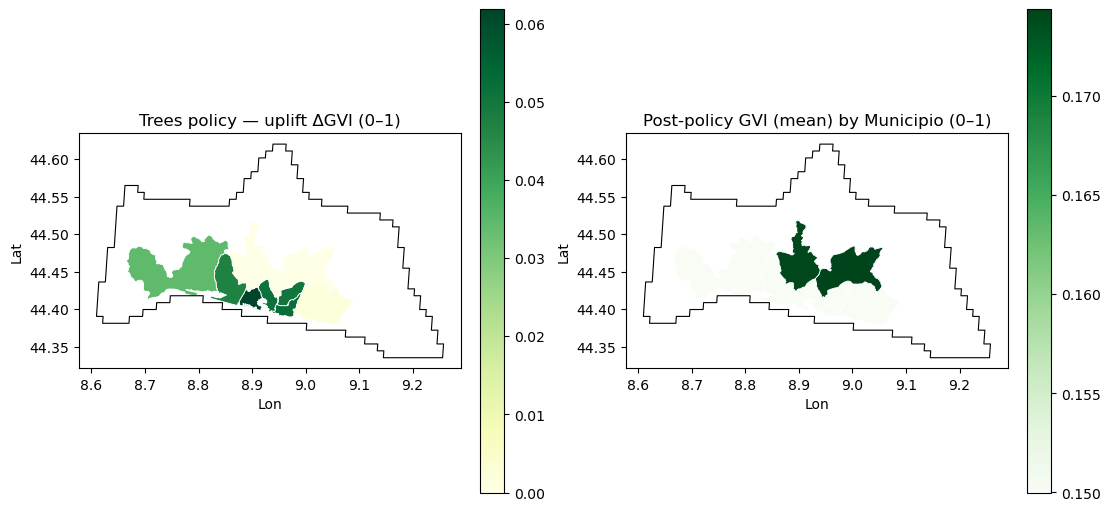

In [30]:
# building plotting frame from kept regions only 
needs_df = pd.DataFrame([{"muni_id": k, "dGVI": v} for k, v in dGVI_needs.items()])
mt = (muni_ok
      .merge(needs_df, on="muni_id", how="left")
      .merge(reg_gvi_ok[["muni_id","muni_name","gvi_mean_0_1"]], on="muni_id", how="left"))
mt["dGVI"]      = mt["dGVI"].fillna(0.0)
mt["gvi_after"] = np.clip(mt["gvi_mean_0_1"] + mt["dGVI"], 0, 1)

def _nudge_for_legend(s: pd.Series, eps=1e-6):
    vmin, vmax = float(s.min()), float(s.max())
    return (vmin, vmax + eps) if np.isclose(vmin, vmax) else (None, None)

dmin, dmax   = _nudge_for_legend(mt["dGVI"])
amin, amax   = _nudge_for_legend(mt["gvi_after"])

fig, ax = plt.subplots(1, 2, figsize=(11,5), constrained_layout=True)

# Left: change in GVI (policy uplift)
fua_4326.boundary.plot(ax=ax[0], color="k", lw=0.8)
mt.plot(ax=ax[0], column="dGVI", cmap="YlGn", legend=True, edgecolor="white", linewidth=0.6,
        vmin=dmin, vmax=dmax)
ax[0].set_title("Trees policy — uplift ΔGVI (0–1)")
ax[0].set_xlabel("Lon"); ax[0].set_ylabel("Lat")

# Right: post-policy mean GVI 
fua_4326.boundary.plot(ax=ax[1], color="k", lw=0.8)
mt.plot(ax=ax[1], column="gvi_after", cmap="Greens", legend=True, edgecolor="white", linewidth=0.6,
        vmin=amin, vmax=amax)
ax[1].set_title("Post-policy GVI (mean) by Municipio (0–1)")
ax[1].set_xlabel("Lon"); ax[1].set_ylabel("Lat")

plt.show()

In [31]:
needs_df = pd.DataFrame([{"muni_id": k, "dGVI": v} for k, v in dGVI_needs.items()])

trees_tbl = (reg_gvi_ok
    .merge(needs_df, on="muni_id", how="left")
    .assign(
        dGVI=lambda d: d["dGVI"].fillna(0.0),
        gvi_after=lambda d: np.clip(d["gvi_mean_0_1"] + d["dGVI"], 0, 1),
        target=lambda d: TARGET,
        cap=lambda d: CAP,
        shortfall_before=lambda d: np.clip(d["target"] - d["gvi_mean_0_1"], 0, None),
        shortfall_after=lambda d: np.clip(d["target"] - d["gvi_after"], 0, None),
        hit_target=lambda d: (d["gvi_after"] + 1e-12) >= d["target"],
        # pretty percent-point columns (optional)
        gvi_mean_pct=lambda d: (d["gvi_mean_0_1"]*100).round(1),
        dGVI_pp=lambda d: (d["dGVI"]*100).round(1),
        gvi_after_pct=lambda d: (d["gvi_after"]*100).round(1),
    )
    .loc[:, ["muni_id","muni_name",
             "gvi_mean_0_1","dGVI","gvi_after",
             "gvi_mean_pct","dGVI_pp","gvi_after_pct",
             "count","pts_per_km2",
             "target","cap","shortfall_before","shortfall_after","hit_target"]]
    .sort_values("muni_id")
)

display(trees_tbl)

,muni_id,muni_name,gvi_mean_0_1,dGVI,gvi_after,gvi_mean_pct,dGVI_pp,gvi_after_pct,count,pts_per_km2,target,cap,shortfall_before,shortfall_after,hit_target
0,1,Bassa Val Bisagno,0.099696,0.050304,0.150000,10.0,5.0,15.0,59,7.433051,0.15,0.12,0.050304,0.0,True
1,2,Centro Est,0.098594,0.051406,0.150000,9.9,5.1,15.0,64,8.286220,0.15,0.12,0.051406,0.0,True
2,3,Centro Ovest,0.088139,0.061861,0.150000,8.8,6.2,15.0,47,6.112047,0.15,0.12,0.061861,0.0,True
3,4,Levante,0.147854,0.002146,0.150000,14.8,0.2,15.0,68,1.859625,0.15,0.12,0.002146,0.0,True
4,5,Media Val Bisagno,0.174367,0.000000,0.174367,17.4,0.0,17.4,97,2.320372,0.15,0.12,0.000000,0.0,True
5,6,Medio Levante,0.097808,0.052192,0.150000,9.8,5.2,15.0,31,5.086412,0.15,0.12,0.052192,0.0,True
6,7,Medio Ponente,0.103073,0.046927,0.150000,10.3,4.7,15.0,69,3.094028,0.15,0.12,0.046927,0.0,True
7,8,Ponente,0.115508,0.034492,0.150000,11.6,3.4,15.0,95,1.227244,0.15,0.12,0.034492,0.0,True
8,9,Val Polcevera,0.174166,0.000000,0.174166,17.4,0.0,17.4,69,2.080275,0.15,0.12,0.000000,0.0,True


In [32]:
# trees_tbl already = kept regions only (from reg_gvi_ok)
total_01  = float(trees_tbl["dGVI"].astype(float).sum())
total_pts = total_01 * 100.0

print(f"Sum of needs across regions (0–1): {total_01:.6f}")
print(f"Sum of needs across regions (points on 1–100): {total_pts:.4f}")

Sum of needs across regions (0–1): 0.299328
Sum of needs across regions (points on 1–100): 29.9328


<blockquote style="border-left:4px solid #ccc; padding-left:1em;">

- dGVI: per-Municipio uplift: how many extra GVI points (on the 0–1 scale) each Municipio gets under the policy.
  
- The sum of dGVI across Municipi gives us the change in GVI due to the policy that we will then use in the CBA.

- Citywide ΔGVI (pop-weighted over Municipi) is the single citywide average uplift experienced by the average resident. It’s computed on the grid by weighting each pixel’s uplift by its population and then averaging across all Municipi pixels included in the policy. On the 0–100 index, that’s *100. 
  
- They are different because citywide number is not the simple mean of the dGVI column. Heavily populated pixels/Municipi count more than lightly populated ones. So areas with many residents but small uplift can raise or decrease the citywide number, even if some Municipi get big dGVI.
  
- Some Municipi have dGVI = 0 because they’re already at/above the target: they enter the population-weighted average too.

- Any excluded Municipio (e.g., Ostia) doesn’t contribute to the citywide diagnostic, by design.
</blockquote>

**From Variation in GVI to variation of T2M (by month and LCZ)**

In [33]:
# We now want the outer_2_mean coeff, different column : city => need the token/alias
import unicodedata, difflib
import numpy as np, pandas as pd
from pathlib import Path

p_CoolEff = P("CoolingEff")
cool_csv_path = (p_CoolEff / "outer_2_mean.csv").resolve()
assert cool_csv_path.exists(), f"Missing {cool_csv_path} — sync CoolingEff."

df = pd.read_csv(cool_csv_path)

def _norm(s):
    return "".join(c for c in unicodedata.normalize("NFKD", str(s).lower())
                   if not unicodedata.combining(c))

# tokens for this city
aliases_cfg = cfg.get("cooling_city_aliases") or cfg.get("cooling_city_tokens") or []
if isinstance(aliases_cfg, str): 
    aliases_cfg = [aliases_cfg]
tokens = {_norm(t) for t in aliases_cfg} | {_norm(SLUG), _norm(CITY.split()[0])}

# exact match on UC_NM_MN 
name_norm = df["UC_NM_MN"].astype(str).map(_norm)
mask = name_norm.isin(tokens)
cool_city = df.loc[mask].copy()

if cool_city.empty:
    cand = sorted(name_norm.unique())
    target = next(iter(tokens))
    guess = difflib.get_close_matches(target, cand, n=1, cutoff=0.6)
    if guess:
        cool_city = df.loc[name_norm == guess[0]].copy()
    else:
        raise RuntimeError(f"No rows in {cool_csv_path.name} for tokens {sorted(tokens)}")

# keep only needed cols; accept 'LCZ' or 'lcz'
lcz_col = "lcz" if "lcz" in cool_city.columns else ("LCZ" if "LCZ" in cool_city.columns else None)
assert lcz_col is not None, "Cooling CSV must have an LCZ column (lcz/LCZ)."
cool_city = cool_city[["month", lcz_col, "coef"]].rename(columns={lcz_col: "lcz"}).copy()

# LCZ name -> code
LCZ_NAME_TO_CODE = {
    "Compact highrise":1,"Compact midrise":2,"Compact lowrise":3,
    "Open highrise":4,"Open midrise":5,"Open lowrise":6,
    "Lightweight low-rise":7,"Lightweight low rise":7,
    "Large lowrise":8,"Sparsely built":9,"Heavy industry":10,
    "Dense trees":11,"Scattered trees":12,"Bush, scrub":13,
    "Low plants":14,"Bare rock/paved":15,"Bare soil/sand":16,"Water":17,
}
cool_city["lcz_code"] = (cool_city["lcz"].astype(str).str.strip()
                         .map(lambda s: LCZ_NAME_TO_CODE.get(s, np.nan))).astype("float")
cool_city = cool_city.dropna(subset=["lcz_code"]).astype({"month":"int","coef":"float"})
cool_city["lcz_code"] = cool_city["lcz_code"].astype(int)

print(f"{CITY} T-mean coeffs from {cool_csv_path.name}:", cool_city.shape)
display(cool_city.head())

Genova T-mean coeffs from outer_2_mean.csv: (96, 4)


,month,lcz,coef,lcz_code
3288,1,Compact highrise,-0.107355,1
3289,2,Compact highrise,-0.102475,1
3290,3,Compact highrise,-0.072901,1
3291,4,Compact highrise,-0.055771,1
3292,5,Compact highrise,-0.044913,1


**VERY IMPORTANT EXPLANATION ABOUT THIS:**
Here, to find the change in temperatures due to the vegetation policy, looking at the cooling coefficients, important to understand that we are not taking the change in GVI due to the policy in the sense of the population weighted change in GVI (2.32 1-100), or neither the sum of change in GVI for each municipio (like for the parametrisation of the vegetation costs in the CBA), but the dGVI_points, that is spatially where each pixel shows GVI change (0-100 scale). For each pixel, dT = coeff * dGVI_points(pixel) ie each pixel gets cooled accordingly to its own GVI increase. Cooling calculation: for each pixel, we lookup the LCZ type, and get cooling coeff for LCZ and month. So, imagining that Municipio I gets a dGVI of 0.056 ie 5.6 (1-100), and Municipi V: 0.049 ie 4.9. It means that each pixel in Muni I gets 5.6 and each pixel in Muni V : 4.9. The temperature change is computed pixel by pixel with c : a 2D array of coeff (one per pixel based on pixel's LVZ) and dGVI points, a 2D array of per pixel GVI changes (from 0 to 12 points depending on which Muni pixels is in); element wise multiplication of 2 grids : each pixel gets its own dT based on its own dGVI point value. 

**Cooling efficiency to monthly change in Temp on the UrbClim grid (ref grid)**

In [34]:
# change in GVI in "points" (0–100) from policy map on ref grid 
dGVI_points = (dGVI_map_model * 100.0).astype("float32")  # zeros outside policy scope

# Monthly change in T (°C) on ref grid by LCZ and month 
months = range(1, 12+1)
coef_lut = {(int(r.month), int(r.lcz_code)): float(r.coef) for r in cool_city.itertuples(index=False)}
built_mask = (lcz_on_ref >= 1) & (lcz_on_ref <= 10) & HAZ_MASK

max_lcz = int(np.nanmax(lcz_on_ref))
dT_month_ref = []
for m in months:
    lcz2coef = np.zeros(max_lcz + 1, dtype=float)
    for (mm, ll), cc in coef_lut.items():
        if mm == m and ll <= max_lcz:
            lcz2coef[ll] = cc
    c = lcz2coef[np.clip(lcz_on_ref, 0, max_lcz)]
    dT = np.where(built_mask, c * dGVI_points, 0.0).astype("float32")  # °C
    # cooling-only
    dT = np.minimum(dT, 0.0).astype("float32")
    dT_month_ref.append(dT)

dT_month_ref = np.stack(dT_month_ref, axis=0)  # (12, H, W)
print("ΔT (°C) monthly min/median/max:",
      float(np.nanmin(dT_month_ref)), 
      float(np.nanmedian(dT_month_ref[np.isfinite(dT_month_ref)])),
      float(np.nanmax(dT_month_ref)))

ΔT (°C) monthly min/median/max: -0.709441065788269 0.0 0.0


-1.9967 is the maximum cooling at the most affected pixel. 

Citywide ΔGVI (pop-weighted over kept regions) ≈ 3.32 points (= 0.0332 on 0–1 scale)
Share of population with ΔGVI>0: 78.8%
ΔGVI citywide (points) — grid vs scalar: 3.324 vs 3.324
Pop-weighted ΔT by month (°C, Jan..Dec): [-0.08  -0.076 -0.054 -0.041 -0.033 -0.027 -0.024 -0.024 -0.028 -0.035
 -0.048 -0.065]
Annual mean pop-weighted ΔT (°C): -0.04468171481563915


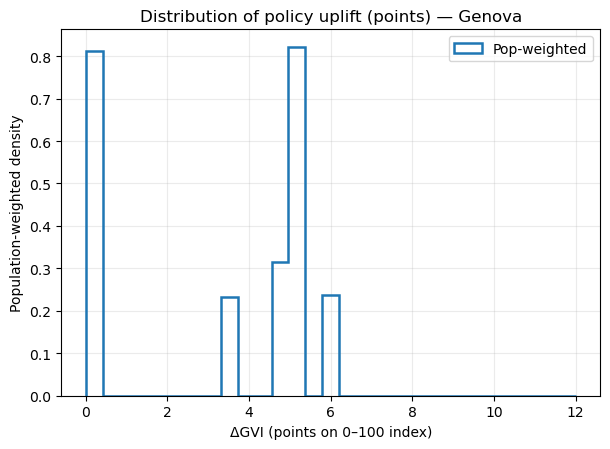

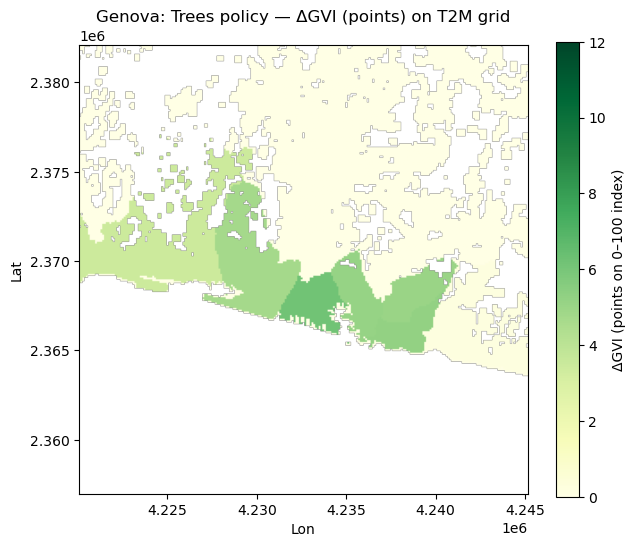

,muni_id,ΔGVI_points_popw,muni_name
0,3,6.186108,Centro Ovest
1,6,5.219242,Medio Levante
2,2,5.140640,Centro Est
3,1,5.030361,Bassa Val Bisagno
4,7,4.692669,Medio Ponente
5,8,3.449195,Ponente
6,4,0.214635,Levante
7,5,0.000000,Media Val Bisagno
8,9,0.000000,Val Polcevera


In [35]:
# change in GVI diagnostics (points on 0–100 index), on the T2M (UrbClim) grid
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from rasterio.transform import array_bounds

# using the policy scope and weights defined earlier (kept Municipi only)
assert 'POLICY' in globals() and 'WEIGHTS' in globals()
den_w = float(np.nansum(WEIGHTS))
if den_w == 0:
    raise RuntimeError("Population weights are zero on POLICY scope—check pop_on_ref / POLICY.")

pw_mean_points = float(np.nansum(dGVI_points * WEIGHTS) / den_w)
print(f"Citywide ΔGVI (pop-weighted over kept regions) ≈ {pw_mean_points:.2f} points "
      f"(= {pw_mean_points/100:.4f} on 0–1 scale)")

share_people_uplift = float(np.nansum((dGVI_points > 0) * WEIGHTS) / den_w)
print(f"Share of population with ΔGVI>0: {share_people_uplift:.1%}")

# consistency check with earlier scalar
if 'dGVI_city_pw' in globals() and np.isfinite(dGVI_city_pw):
    print("ΔGVI citywide (points) — grid vs scalar:",
          np.round(100.0 * float(dGVI_city_pw), 3), "vs", np.round(pw_mean_points, 3))

# population-weighted monthly change in T 
if 'dT_month_ref' in globals():
    pw_dT_month = [float(np.nansum(dT * WEIGHTS) / den_w) for dT in dT_month_ref]
    print("Pop-weighted ΔT by month (°C, Jan..Dec):", np.round(pw_dT_month, 3))
    print("Annual mean pop-weighted ΔT (°C):", float(np.nanmean(pw_dT_month)))

# Histogram (population-weighted)
m = POLICY & np.isfinite(dGVI_points) & (WEIGHTS > 0)
v = dGVI_points[m].ravel()
w = WEIGHTS[m].ravel()
cap_pts = int(round(CAP * 100))  # CAP from YAML, in points
vmax = (np.nanmax(v) if v.size else 1.0)
vmax_bins = cap_pts if np.isfinite(cap_pts) and cap_pts > 0 else (vmax if np.isfinite(vmax) else 1.0)
bins = np.linspace(0, max(1.0, float(vmax_bins)), 30)

plt.figure(figsize=(6.2, 4.6))
plt.hist(v, bins=bins, weights=w, histtype="step", linewidth=1.8, density=True, label="Pop-weighted")
plt.xlabel("ΔGVI (points on 0–100 index)"); plt.ylabel("Population-weighted density")
plt.title(f"Distribution of policy uplift (points) — {CITY}")
plt.grid(alpha=0.25); plt.legend(); plt.tight_layout(); plt.show()

# Map (points), fixed 0..CAP
left, bottom, right, top = array_bounds(HGT, WDT, ref_meta["transform"])
extent = (left, right, bottom, top)
plt.figure(figsize=(6.6, 5.5))
im = plt.imshow(np.where(CITY_MASK, dGVI_points, np.nan), origin="upper",
                extent=extent, vmin=0, vmax=cap_pts, cmap="YlGn")
cb = plt.colorbar(im); cb.set_label("ΔGVI (points on 0–100 index)")
plt.title(f"{CITY}: Trees policy — ΔGVI (points) on T2M grid")
plt.xlabel("Lon"); plt.ylabel("Lat"); plt.tight_layout(); plt.show()

# Municipio table in points (population-weighted)
if 'muni_ok' in globals():
    ids = muni_on_ref[POLICY].astype(int)
    w   = WEIGHTS[POLICY]
    x   = dGVI_points[POLICY]
    size = int(np.nanmax(muni_on_ref)) + 1
    den = np.bincount(ids, weights=w, minlength=size)
    num = np.bincount(ids, weights=w*x, minlength=size)
    by_muni = pd.DataFrame({
        "muni_id": np.arange(size, dtype=int),
        "ΔGVI_points_popw": np.divide(num, den, out=np.full_like(num, np.nan), where=den > 0)
    })
    out = (by_muni.merge(muni_ok[["muni_id", "muni_name"]], on="muni_id", how="inner")
                  .sort_values("ΔGVI_points_popw", ascending=False))
    display(out.reset_index(drop=True).head(10))

Coefficients say how many °C cooler per +1 GVI point for each month×LCZ. Multiplying by policy’s ΔGVI (in points) gives a monthly cooling map. Careful: we zero it outside built areas.

**Adding trees' cooling (°C) to the daily T2M hazard (same grid)**

In [36]:
from copy import deepcopy
import numpy as np, pandas as pd
from scipy import sparse

# daily month index from the hazard H 
dates   = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))
mon_idx = dates.dt.month.to_numpy(int)   # values in 1..12

# flatten monthly change in T (°C) to match H.intensity column order 
Hh, Ww = HGT, WDT
assert dT_month_ref.shape == (12, Hh, Ww), "Expected (12, H, W) ΔT stack."

# Note: dT_month_ref already:
# equals 0 outside policy/built areas
# is cooling-only (≤ 0)
dT_month_vec = [dT_month_ref[m-1].reshape(Hh*Ww).astype("float32") for m in range(1, 13)]

# building a sparse matrix with one row/day of ΔT
rows = [dT_month_vec[m-1][None, :] for m in mon_idx]          # list of (1, Ncells)
D_daily = sparse.csr_matrix(np.vstack(rows).astype("float32")) # shape = H.intensity.shape

# apply cooling additively (°C) to the daily hazard
H_trees = deepcopy(H)
H_trees.intensity = H.intensity + D_daily

# sanity checks
def _row_mean(mat):  # citywide mean °C per day
    return np.asarray(mat.mean(axis=1)).ravel()

base_daily = _row_mean(H.intensity)
tree_daily = _row_mean(H_trees.intensity)
delta_daily = tree_daily - base_daily

print("ΔT daily mean (°C) — min/median/max:",
      float(np.min(delta_daily)), float(np.median(delta_daily)), float(np.max(delta_daily)))
print("Sample days:", pd.DataFrame({
    "date": dates.iloc[:5].astype(str).values,
    "base_degC":  base_daily[:5].round(2),
    "tree_degC":  tree_daily[:5].round(2),
    "delta_degC": delta_daily[:5].round(3),
}))

ΔT daily mean (°C) — min/median/max: -0.014170408248901367 -0.006173133850097656 -0.004131317138671875
Sample days:          date  base_degC  tree_degC  delta_degC
0  2030-01-01       3.70       3.68      -0.014
1  2030-01-02       3.58       3.57      -0.014
2  2030-01-03       3.10       3.09      -0.014
3  2030-01-04       3.31       3.30      -0.014
4  2030-01-05       3.33       3.31      -0.014


> **Interpretation:**
> - On each day, after the tree policy, the average temperature across the city is lower by a small, month-specific constant.
> - The three numbers are the spread of the daily city-mean cooling over the whole year built: the strongest average daily cooling we ever get is about −0.085 °C, the typical day is around −0.041 °C, and the weakest is about −0.027 °C
> - Larger in winter because coefficients for mean temperature are a bit more negative there, in summer they’re closer to zero, so the daily shifts are smaller.
> - Citywide mean. Individual pixels cool more or less depending on LCZ and ΔGVI; outside the policy/built areas the change is zero. 

**Apply to hazard and compute impacts**

In [37]:
# will need age_ifs
# age-specific IFs frozen in NB4 and rebuilding `age_ifs` 
import json, numpy as np
from pathlib import Path
from climada.entity.impact_funcs import ImpactFunc

# making sure hazard metadata matches our daily T2M setup
if not getattr(H, "haz_type", None):
    H.haz_type = "T2M"

# load frozen curves
freeze_path = Path(INT) / f"if_curves_frozen_{SLUG}.json"
if not freeze_path.exists():
    fallback = Path(INT) / "if_curves_frozen.json"
    assert fallback.exists(), f"Missing {freeze_path} and {fallback}"
    freeze_path = fallback

with open(freeze_path, "r") as fh:
    IF_FREEZE = json.load(fh)

def _mk_if(v):
    f = ImpactFunc(
        haz_type="T2M",
        id=int(v["id"]),
        intensity=np.asarray(v["intensity"], float),
        mdd=np.asarray(v["mdd"], float),
        paa=np.ones(len(v["intensity"]), float),
        name=v.get("name", "IF"),
    )
    f.check()
    return f

# rebuilding dict keyed by age labels ("<15","15-64","65+")
age_ifs = {k: _mk_if(v) for k, v in IF_FREEZE.items()}

# do exposure IF IDs exist among our set?
if_col = "impf_T2M" if "impf_T2M" in exp.gdf.columns else None
if if_col:
    have = set(int(x) for x in exp.gdf[if_col].dropna().unique())
    made = set(int(v.id) for v in age_ifs.values())
    missing = have - made
    if missing:
        print(f"[warn] Some IF IDs in exposure not rebuilt: {sorted(missing)}")
    else:
        print(f"[ok] Rebuilt IFs cover exposure IDs: {sorted(made)}")

print(f"Loaded {freeze_path.name} with {len(age_ifs)} age IFs.")

[ok] Rebuilt IFs cover exposure IDs: [1, 2, 3]
Loaded if_curves_frozen_genova.json with 3 age IFs.


In [38]:
import numpy as np
import pandas as pd
from pathlib import Path

ac_npz = Path(INT) / f"ac_coverage_maps_{SLUG}.npz"
if not ac_npz.exists():
    ac_npz = Path(INT) / "ac_coverage_maps.npz"  # alias

npz = np.load(ac_npz)

EFF_DEFAULT = float(npz["EFF_DEFAULT"][0]) if "EFF_DEFAULT" in npz.files else 0.30
EFF_MAP = {"default": EFF_DEFAULT}
if "EFF_BUCKETS_LT15" in npz.files:  EFF_MAP["<15"]   = float(npz["EFF_BUCKETS_LT15"][0])
if "EFF_BUCKETS_15_64" in npz.files: EFF_MAP["15-64"] = float(npz["EFF_BUCKETS_15_64"][0])
if "EFF_BUCKETS_65P" in npz.files:   EFF_MAP["65+"]   = float(npz["EFF_BUCKETS_65P"][0])

# printing to confirm what we loaded
print("EFF_MAP:", EFF_MAP)

# careful to not overwrite CITY_MASK we already loaded from city_mask.tif:
CITY_MASK_AC = npz["CITY_MASK"].astype(bool)
assert CITY_MASK_AC.shape == CITY_MASK.shape, "AC NPZ grid != template_ref grid"
if not np.array_equal(CITY_MASK_AC, CITY_MASK):
    print("[warn] CITY_MASK from AC NPZ differs from city_mask.tif. Using city_mask.tif version.")

# 3D cubes (year-varying). falling back to 2D anchor if needed.
cov_base_raw   = npz["coverage_base_3d"]   if "coverage_base_3d"   in npz.files else npz["coverage_base"]
cov_policy_raw = npz["coverage_policy_3d"] if "coverage_policy_3d" in npz.files else npz["coverage_policy"]

# years for the cubes
if "YEARS_AC" in npz.files:
    YEARS_AC = npz["YEARS_AC"].astype(int).tolist()
elif "years" in npz.files:
    YEARS_AC = npz["years"].astype(int).tolist()
else:
    YEARS_AC = None

dates_h = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))
years_h = np.sort(dates_h.dt.year.unique()).astype(int).tolist()

def _build_cov_by_year(arr, years_in_file):
    if arr.ndim == 2:
        # same 2D map for all hazard years
        return {int(y): np.nan_to_num(arr.astype("float32"), nan=0.0) for y in years_h}
    if arr.ndim == 3:
        assert years_in_file is not None, "3D coverage cube but missing YEARS_AC in NPZ"
        assert arr.shape[0] == len(years_in_file), "cube length != YEARS_AC length"
        return {int(y): np.nan_to_num(arr[i].astype("float32"), nan=0.0)
                for i, y in enumerate(years_in_file)}
    raise ValueError(f"Unexpected coverage array dim {arr.ndim}")

coverage_base_by_year   = _build_cov_by_year(cov_base_raw,   YEARS_AC)
coverage_policy_by_year = _build_cov_by_year(cov_policy_raw, YEARS_AC)

print("Loaded:", ac_npz.name)
print("Coverage base example years:", sorted(list(coverage_base_by_year))[:5], "...")
print("Base grid shape:", next(iter(coverage_base_by_year.values())).shape)

EFF_MAP: {'default': 0.30000001192092896, '<15': 0.30000001192092896, '15-64': 0.4000000059604645, '65+': 0.550000011920929}
Loaded: ac_coverage_maps_genova.npz
Coverage base example years: [2030, 2040, 2050] ...
Base grid shape: (251, 251)


In [39]:
import numpy as np
import pandas as pd

import numpy as np
import pandas as pd

# helper is already defined above, but keeping it here for clarity
def _eff_for_age(age_lbl, eff_map=EFF_MAP, eff_default=EFF_DEFAULT):
    if age_lbl in eff_map:
        return float(eff_map[age_lbl])
    for k, v in eff_map.items():
        if k == "default":
            continue
        if k in str(age_lbl):
            return float(v)
    return float(eff_default)

def _row_to_grid(intensity, i_ev, grid_shape):
    row = intensity[i_ev]
    if hasattr(row, "toarray"):
        row = row.toarray()
    row = np.asarray(row, float).ravel()
    expected = grid_shape[0] * grid_shape[1]
    if row.size == expected:
        return row.reshape(grid_shape)
    if row.size == 1:
        return np.full(grid_shape, row[0], dtype=float)
    raise ValueError(f"Row size {row.size} != grid cells {expected} and != 1")

def annual_deaths_with_ac(H_like, coverage_by_year, age_by_year, pop_by_year):
    """
    Annual heat deaths per age group, for a daily T2M hazard H_like,
    using year-specific AC coverage AND year-specific age/pop rasters.

    Returns:
        yr_rates  : DataFrame [years × age_groups+overall], per 100k
        yr_totals : DataFrame [years × age_groups+overall], absolute deaths
    """
    if "age_ifs" not in globals():
        raise NameError("age_ifs not defined (run the IF rebuild cell).")
    if "CITY_MASK" not in globals():
        raise NameError("CITY_MASK not defined.")
    if "ref_data" in globals():
        grid_shape = ref_data.shape
    elif "ref_meta" in globals():
        grid_shape = (int(ref_meta["height"]), int(ref_meta["width"]))
    else:
        raise NameError("Need ref_data or ref_meta to know grid shape.")

    dates = pd.to_datetime(pd.Series(H_like.date.astype("datetime64[ns]")))
    years = np.unique(dates.dt.year.astype(int))
    age_labels = list(age_ifs.keys())

    # precompute denominators per year & age
    age_pops_by_year = {
        int(y): {
            a: float(
                np.nansum(
                    np.nan_to_num(age_by_year[int(y)][a], 0.0)[CITY_MASK]
                )
            )
            for a in age_labels
        }
        for y in years
    }
    city_pop_by_year = {
        int(y): sum(age_pops_by_year[int(y)][a] for a in age_labels)
        for y in years
    }

    totals = {a: pd.Series(0.0, index=years, dtype=float) for a in age_labels}

    for i_ev, d in enumerate(dates):
        y = int(d.year)

        cov_y = coverage_by_year.get(y)
        if cov_y is None:
            raise KeyError(
                f"No coverage grid for year {y}. Have keys: "
                f"{sorted(coverage_by_year.keys())}"
            )
        cov_y = np.nan_to_num(cov_y.astype(float), nan=0.0)

        I_grid = _row_to_grid(H_like.intensity, i_ev, grid_shape)
        m_city = CITY_MASK & np.isfinite(I_grid)

        for age_lbl in age_labels:
            f = age_ifs[age_lbl]
            mdd = np.interp(
                I_grid, f.intensity, f.mdd, left=f.mdd[0], right=f.mdd[-1]
            )

            eff_a = _eff_for_age(age_lbl)
            mult  = np.clip(1.0 - eff_a * cov_y, 0.0, 1.0)

            pop_a_grid = np.nan_to_num(age_by_year[y][age_lbl], 0.0)

            deaths_day = np.where(m_city, pop_a_grid * mdd * mult, 0.0)
            totals[age_lbl].loc[y] += float(np.nansum(deaths_day))

    yr_totals = pd.DataFrame(totals).sort_index()
    yr_totals["overall"] = yr_totals[age_labels].sum(axis=1)

    # per 100k
    yr_rates = yr_totals.copy()

    for age_lbl in age_labels:
        denom_series = pd.Series(
            {int(y): age_pops_by_year[int(y)][age_lbl] for y in years},
            index=years,
        )
        yr_rates[age_lbl] = (
            yr_totals[age_lbl] / denom_series * 1e5
        ).where(denom_series > 0, np.nan)

    overall_denom = pd.Series(
        {int(y): city_pop_by_year[int(y)] for y in years},
        index=years,
    )
    yr_rates["overall"] = (
        yr_totals["overall"] / overall_denom * 1e5
    ).where(overall_denom > 0, np.nan)

    return yr_rates, yr_totals

    print("[ok] annual_deaths_with_ac() was missing and is now defined.")

In [40]:
# Current AC baseline
yr_rates_base,  yr_totals_base  = annual_deaths_with_ac(
    H,       coverage_base_by_year,   age_on_ref_by_year, pop_on_ref_by_year
)

# Trees only (same AC coverage, different hazard)
yr_rates_trees, yr_totals_trees = annual_deaths_with_ac(
    H_trees, coverage_base_by_year,   age_on_ref_by_year, pop_on_ref_by_year
)

# AC policy only
yr_rates_ac,    yr_totals_ac    = annual_deaths_with_ac(
    H,       coverage_policy_by_year, age_on_ref_by_year, pop_on_ref_by_year
)

# Trees + AC policy
yr_rates_both,  yr_totals_both  = annual_deaths_with_ac(
    H_trees, coverage_policy_by_year, age_on_ref_by_year, pop_on_ref_by_year
)

In [41]:
# Avoided deaths vs "current AC" baseline
# making sure indices/years line up
common_years = (
    yr_totals_base.index
    .intersection(yr_totals_ac.index)
    .intersection(yr_totals_both.index)
    .intersection(yr_totals_trees.index)
)

base  = yr_totals_base.loc[common_years]
ac    = yr_totals_ac.loc[common_years]
both  = yr_totals_both.loc[common_years]
trees = yr_totals_trees.loc[common_years]

# AC policy vs current AC
avo_totals_ac = base - ac

# Trees + AC vs current AC
avo_totals_both = base - both

# Trees only vs current AC
avo_totals_trees = base - trees

# Trees on top of AC policy (extra benefit of trees conditional on the policy)
avo_totals_tree_cond = ac - both

In [42]:
out_dir = Path(INT)
out_dir.mkdir(parents=True, exist_ok=True)

for df in (yr_totals_ac, yr_totals_both,
           avo_totals_ac, avo_totals_both, avo_totals_tree_cond):
    df.index.name = "year"

# AC policy only deaths
yr_totals_ac.to_csv(
    out_dir / f"annual_heat_deaths_curr_AC_ACpolicy_{SLUG}.csv"
)

# Trees + AC policy deaths
yr_totals_both.to_csv(
    out_dir / f"annual_heat_deaths_curr_AC_treesplusAC_{SLUG}.csv"
)

# Avoided deaths vs current AC
avo_totals_ac.to_csv(
    out_dir / f"annual_heat_deaths_avoided_AC_curr_AC_{SLUG}.csv"
)
avo_totals_both.to_csv(
    out_dir / f"annual_heat_deaths_avoided_treesplusAC_curr_AC_{SLUG}.csv"
)
avo_totals_tree_cond.to_csv(
    out_dir / f"annual_heat_deaths_avoided_trees_on_top_AC_curr_AC_{SLUG}.csv"
)

avo_totals_trees.to_csv(
    out_dir / f"annual_heat_deaths_avoided_trees_curr_AC_{SLUG}.csv"
)

APPLY_BASELINE_SCALING = globals().get("APPLY_BASELINE_SCALING", False)  # set True if you want scaling

# SCALED versions if we want
if APPLY_BASELINE_SCALING and all(k in globals() for k in [
    "yr_totals_ac_sc", "yr_totals_both_sc",
    "avo_totals_ac_sc", "avo_totals_both_sc", "avo_totals_tree_cond_sc"
]):
    for df in (yr_totals_ac_sc, yr_totals_both_sc,
               avo_totals_ac_sc, avo_totals_both_sc, avo_totals_tree_cond_sc):
        df.index.name = "year"

    yr_totals_ac_sc.to_csv(out_dir / f"annual_heat_deaths_curr_AC_ACpolicy_scaled_{SLUG}.csv")
    yr_totals_both_sc.to_csv(out_dir / f"annual_heat_deaths_curr_AC_treesplusAC_scaled_{SLUG}.csv")
    avo_totals_ac_sc.to_csv(out_dir / f"annual_heat_deaths_avoided_AC_curr_AC_scaled_{SLUG}.csv")
    avo_totals_both_sc.to_csv(out_dir / f"annual_heat_deaths_avoided_treesplusAC_curr_AC_scaled_{SLUG}.csv")
    avo_totals_tree_cond_sc.to_csv(out_dir / f"annual_heat_deaths_avoided_trees_on_top_AC_curr_AC_scaled_{SLUG}.csv")
else:
    print("Skipping scaled outputs (APPLY_BASELINE_SCALING is False or scaled tables not computed).")

Skipping scaled outputs (APPLY_BASELINE_SCALING is False or scaled tables not computed).


In [43]:
from pathlib import Path
import pandas as pd
from IPython.display import display

out_dir = Path(INT)
out_dir.mkdir(parents=True, exist_ok=True)

# tables
tables = {
    "yr_totals_base": yr_totals_base,
    "yr_totals_trees": yr_totals_trees,
    "yr_totals_acpolicy": yr_totals_ac,
    "yr_totals_treesplusAC": yr_totals_both,
    "avo_totals_trees": avo_totals_trees,
    "avo_totals_acpolicy": avo_totals_ac,
    "avo_totals_treesplusAC": avo_totals_both,
    "avo_totals_trees_on_top_AC": avo_totals_tree_cond,

    "yr_rates_base_per100k": yr_rates_base,
    "yr_rates_trees_per100k": yr_rates_trees,
    "yr_rates_acpolicy_per100k": yr_rates_ac,
    "yr_rates_treesplusAC_per100k": yr_rates_both,
}

# scaled tables if exist 
if globals().get("APPLY_BASELINE_SCALING", False):
    for k in ["yr_totals_ac_sc", "yr_totals_both_sc",
              "avo_totals_ac_sc", "avo_totals_both_sc", "avo_totals_tree_cond_sc"]:
        if k in globals():
            tables[k] = globals()[k]

pd.set_option("display.max_columns", None)
for name, df in tables.items():
    print("\n" + "="*80)
    print(name)
    display(df.round(3))

# one Excel with a sheet per table
xlsx_path = out_dir / f"annual_heat_deaths_AC_bundle_{SLUG}.xlsx"
with pd.ExcelWriter(xlsx_path) as writer:
    for name, df in tables.items():
        sheet = name[:31]  # Excel sheet-name limit
        df.to_excel(writer, sheet_name=sheet)

print("\nSaved Excel bundle to:", xlsx_path)


yr_totals_base


,<15,15-64,65+,overall
2030,0.277,5.244,39.729,45.251
2040,0.290,5.038,52.621,57.949
2050,0.294,4.368,52.107,56.769



yr_totals_trees


,<15,15-64,65+,overall
2030,0.275,5.180,39.149,44.603
2040,0.288,4.978,51.887,57.153
2050,0.292,4.316,51.361,55.968



yr_totals_acpolicy


...


yr_rates_acpolicy_per100k


,<15,15-64,65+,overall
2030,0.504,1.477,19.093,7.155
2040,0.541,1.630,21.419,9.349
2050,0.520,1.540,19.969,9.273



yr_rates_treesplusAC_per100k


,<15,15-64,65+,overall
2030,0.499,1.459,18.806,7.050
2040,0.536,1.610,21.112,9.217
2050,0.515,1.521,19.676,9.139



Saved Excel bundle to: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/annual_heat_deaths_AC_bundle_genova.xlsx


We will need this for our CBA

For all the following code need to choose if I want the scaled version or not

But as I said before, I will actually just delete all this scaling story (now we use the actual right population as exposure, changing over time). 

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rasterio.transform import array_bounds
from pathlib import Path

years_wanted = [2030, 2040, 2050]
MAKE_MAPS = False          # True if want the raster maps plotted
TOP_N = 10                 # show top N municipi per year
SAVE = True                # save outputs for CBA

# dates + hazard years
dates = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))
years_h = np.sort(dates.dt.year.unique()).astype(int).tolist()
years_run = [y for y in years_wanted if y in years_h]
if not years_run:
    raise ValueError(f"None of {years_wanted} are in hazard years: {years_h[:10]} ...")

Hh, Ww = int(ref_meta["height"]), int(ref_meta["width"])

# loading AC baseline maps (prefer dynamic cube: not 2D, we need the year)
npz = np.load(INT / f"ac_coverage_maps_{SLUG}.npz")
CITY_MASK = npz["CITY_MASK"].astype(bool)

coverage_base_raw = npz["coverage_base_3d"] if "coverage_base_3d" in npz.files else npz["coverage_base"]
years_in_npz = (
    npz["YEARS_AC"] if "YEARS_AC" in npz.files
    else (npz["years"] if "years" in npz.files else None)
)

def _build_cov_by_year(arr, years_in_file=None):
    if arr.ndim == 2:
        return {int(y): arr.astype(float) for y in years_h}
    if arr.ndim == 3:
        ys = [int(y) for y in (years_in_file if years_in_file is not None else years_h)]
        if arr.shape[0] != len(ys):
            raise ValueError(f"coverage cube has {arr.shape[0]} years but years list has {len(ys)}")
        return {int(y): arr[i].astype(float) for i, y in enumerate(ys)}
    raise ValueError(f"Unexpected coverage array dim {arr.ndim}")

coverage_base_by_year = _build_cov_by_year(coverage_base_raw, years_in_npz)

def _interp_mdd(intensity_2d, f):
    return np.interp(intensity_2d, f.intensity, f.mdd, left=f.mdd[0], right=f.mdd[-1])

def _row_to_grid(mat, irow, shape):
    row = mat[irow, :]
    if hasattr(row, "toarray"):
        row = row.toarray()
    return np.asarray(row).ravel().reshape(shape)

# extent for maps
left, bottom, right, top = array_bounds(Hh, Ww, ref_meta["transform"])
extent = (left, right, bottom, top)

# municipio frame
M = muni_ok if "muni_ok" in globals() else muni
ids_full = muni_on_ref.astype(int)

results = {}  

for year in years_run:
    rows_year = np.where(dates.dt.year.to_numpy(int) == int(year))[0]
    if rows_year.size == 0:
        continue

    if int(year) not in coverage_base_by_year:
        raise KeyError(f"No AC coverage grid for year {year}. Have keys like: {sorted(list(coverage_base_by_year))[:10]} ...")
    cov_y = coverage_base_by_year[int(year)].astype(float)

    deaths_base_pix  = np.zeros((Hh, Ww), dtype=float)
    deaths_trees_pix = np.zeros((Hh, Ww), dtype=float)

    for r in rows_year:
        I_b = _row_to_grid(H.intensity,       r, (Hh, Ww))
        I_t = _row_to_grid(H_trees.intensity, r, (Hh, Ww))

        day_base  = np.zeros((Hh, Ww), dtype=float)
        day_trees = np.zeros((Hh, Ww), dtype=float)

        for age_lbl, f in age_ifs.items():
            mdd_b = _interp_mdd(I_b, f)
            mdd_t = _interp_mdd(I_t, f)

            eff_a = _eff_for_age(age_lbl, EFF_MAP, EFF_DEFAULT)
            mult  = np.clip(1.0 - eff_a * cov_y, 0.0, 1.0)
            
            pop_a = np.nan_to_num(age_on_ref_by_year[int(year)][age_lbl], 0.0)

            day_base  += pop_a * mdd_b * mult
            day_trees += pop_a * mdd_t * mult

        deaths_base_pix  += np.where(CITY_MASK, day_base,  0.0)
        deaths_trees_pix += np.where(CITY_MASK, day_trees, 0.0)

    deaths_avo_pix = deaths_base_pix - deaths_trees_pix
    city_avo_total = float(np.nansum(deaths_avo_pix[CITY_MASK]))

    # municipio table
    rows = []
    for mid, name in zip(M["muni_id"], M["muni_name"]):
        m = (ids_full == int(mid)) & CITY_MASK
        pop_grid_y = pop_on_ref_by_year[int(year)]
        pop_m = sum(float(np.nansum(age_on_ref_by_year[int(year)][a][m]))
                    for a in age_ifs) if m.any() else 0.0
        d_b   = float(np.nansum(deaths_base_pix[m]))  if m.any() else 0.0
        d_t   = float(np.nansum(deaths_trees_pix[m])) if m.any() else 0.0
        d_avo = d_b - d_t
        rows.append({
            "year": int(year),
            "muni_id": int(mid),
            "muni_name": name,
            "deaths_base": d_b,
            "deaths_trees": d_t,
            "deaths_avo": d_avo,
            "avo_per_100k": (d_avo / pop_m * 1e5) if pop_m > 0 else 0.0,
        })

    tbl = (pd.DataFrame(rows)
           .sort_values("deaths_avo", ascending=False)
           .reset_index(drop=True))

    results[int(year)] = {"tbl": tbl, "city_avo": city_avo_total, "deaths_avo_pix": deaths_avo_pix}

    print(f"{CITY} {year} — avoided deaths with current AC (trees vs baseline): {city_avo_total:.3f}")
    display(tbl.head(TOP_N))

    if MAKE_MAPS:
        plt.figure(figsize=(6.6, 5.4))
        im = plt.imshow(np.where(CITY_MASK, deaths_avo_pix, np.nan), origin="upper", extent=extent)
        cb = plt.colorbar(im); cb.set_label("Avoided deaths (year total, with AC)")
        plt.title(f"{CITY} — Avoided deaths (trees − baseline, with AC), {year}")
        plt.xlabel("ETRS89 / LAEA X (m)"); plt.ylabel("ETRS89 / LAEA Y (m)")
        plt.tight_layout(); plt.show()

# city summary table
summary = (pd.DataFrame({
    "year": sorted(results.keys()),
    "city_avoided_deaths": [results[y]["city_avo"] for y in sorted(results.keys())],
}).sort_values("year"))
display(summary)

# one long table (all municipi, all years)
tbl_all = pd.concat([results[y]["tbl"] for y in sorted(results.keys())], ignore_index=True)

# save for CBA
if SAVE:
    out_dir = Path(OUT) / "tables"
    out_dir.mkdir(parents=True, exist_ok=True)

    tbl_all.to_csv(out_dir / f"{SLUG}_muni_avoided_deaths_currAC_trees_{years_run[0]}_{years_run[-1]}.csv", index=False)
    summary.to_csv(out_dir / f"{SLUG}_city_avoided_deaths_currAC_trees_summary.csv", index=False)

    xlsx_path = out_dir / f"{SLUG}_avoided_deaths_currAC_trees_muni_{years_run[0]}_{years_run[-1]}.xlsx"
    with pd.ExcelWriter(xlsx_path) as w:
        summary.to_excel(w, sheet_name="city_summary", index=False)
        tbl_all.to_excel(w, sheet_name="muni_all_years", index=False)
        for y in sorted(results.keys()):
            results[y]["tbl"].to_excel(w, sheet_name=f"muni_{y}", index=False)

    print("Saved:", xlsx_path)

Genova 2030 — avoided deaths with current AC (trees vs baseline): 0.647


,year,muni_id,muni_name,deaths_base,deaths_trees,deaths_avo,avo_per_100k
0,2030,7,Medio Ponente,7.199254,7.043104,0.156150,0.221743
1,2030,8,Ponente,5.865397,5.719660,0.145736,0.281170
2,2030,1,Bassa Val Bisagno,3.113227,2.984283,0.128944,0.280907
3,2030,3,Centro Ovest,6.441772,6.338577,0.103195,0.195502
4,2030,6,Medio Levante,3.297195,3.217805,0.079391,0.113241
5,2030,2,Centro Est,1.454802,1.427496,0.027306,0.040355
6,2030,4,Levante,2.508617,2.502546,0.006071,0.009084
7,2030,5,Media Val Bisagno,4.347402,4.347402,0.000000,0.000000
8,2030,9,Val Polcevera,8.476975,8.476975,0.000000,0.000000


Genova 2040 — avoided deaths with current AC (trees vs baseline): 0.795


,year,muni_id,muni_name,deaths_base,deaths_trees,deaths_avo,avo_per_100k
0,2040,7,Medio Ponente,9.169820,8.978860,0.190960,0.273122
1,2040,8,Ponente,7.433665,7.255454,0.178211,0.346293
2,2040,1,Bassa Val Bisagno,4.021682,3.862846,0.158836,0.348512
3,2040,3,Centro Ovest,8.211642,8.085501,0.126140,0.240686
4,2040,6,Medio Levante,4.253732,4.154961,0.098771,0.141896
5,2040,2,Centro Est,1.955587,1.920601,0.034986,0.052076
6,2040,4,Levante,3.201845,3.194292,0.007553,0.011382
7,2040,5,Media Val Bisagno,5.626656,5.626656,0.000000,0.000000
8,2040,9,Val Polcevera,10.854511,10.854511,0.000000,0.000000


Genova 2050 — avoided deaths with current AC (trees vs baseline): 0.801


,year,muni_id,muni_name,deaths_base,deaths_trees,deaths_avo,avo_per_100k
0,2050,7,Medio Ponente,9.013753,8.820601,0.193153,0.279902
1,2050,8,Ponente,7.322130,7.141797,0.180334,0.355041
2,2050,1,Bassa Val Bisagno,3.908613,3.748695,0.159918,0.355514
3,2050,3,Centro Ovest,8.094999,7.968137,0.126862,0.245256
4,2050,6,Medio Levante,4.124801,4.025871,0.098930,0.143999
5,2050,2,Centro Est,1.846870,1.812728,0.034142,0.051490
6,2050,4,Levante,3.096277,3.088809,0.007468,0.011402
7,2050,5,Media Val Bisagno,5.491266,5.491266,0.000000,0.000000
8,2050,9,Val Polcevera,10.728120,10.728120,0.000000,0.000000


,year,city_avoided_deaths
0,2030,0.646793
1,2040,0.795458
2,2050,0.800806


Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/tables/genova_avoided_deaths_currAC_trees_muni_2030_2050.xlsx


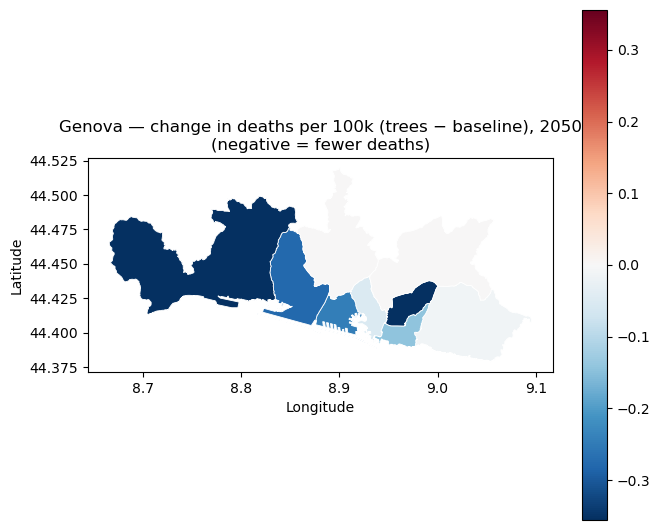

In [45]:
# Map: change in deaths per 100k (trees − baseline), negative = fewer deaths 
import numpy as np
import matplotlib.pyplot as plt

year_focus = 2050          # or 2030 / 2040
tbl_muni = results[year_focus]["tbl"].copy()

plot_cols = ["muni_id", "avo_per_100k", "deaths_avo"]
m_tbl = tbl_muni[plot_cols].copy()
m_tbl["delta_per100k"] = -m_tbl["avo_per_100k"]  # trees − baseline

# joining to geometry
muni_map = muni_ok.merge(m_tbl[["muni_id", "delta_per100k"]], on="muni_id", how="left")

vals = muni_map["delta_per100k"].to_numpy(dtype=float)
vmax = np.nanmax(np.abs(vals)) if np.isfinite(vals).any() else 1.0
vmin = -vmax

ax = muni_map.plot(
    column="delta_per100k",
    cmap="RdBu_r",
    vmin=vmin, vmax=vmax,
    linewidth=0.6, edgecolor="white",
    legend=True, figsize=(6.8, 5.4)
)
ax.set_title(f"{CITY} — change in deaths per 100k (trees − baseline), {year_focus}\n(negative = fewer deaths)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout(); plt.show()

In [46]:
# City avoided deaths by age in the focus year (with current AC baseline)

import numpy as np
import pandas as pd

year_focus = int(((cfg or {}).get("trees", {}) or {}).get("focus_year", 2050))

# yr_totals_base / yr_totals_trees are from annual_deaths_with_ac (AC-aware)
if year_focus not in yr_totals_base.index:
    raise ValueError(f"No yearly totals for focus year {year_focus} in AC-aware tables.")

# Age groups to report (exclude 'overall')
age_cols = [c for c in yr_totals_base.columns if c != "overall"]

avo_city_age = {}
per100k_age  = {}

for age_lbl in age_cols:
    d_b   = float(yr_totals_base.loc[year_focus,  age_lbl])
    d_t   = float(yr_totals_trees.loc[year_focus, age_lbl])
    d_avo = d_b - d_t  # avoided deaths with trees under current AC

    # population for this age group (same as in annual_deaths_with_ac)
    pop_age = float(
        np.nansum(
            np.nan_to_num(age_on_ref_by_year[year_focus][age_lbl], 0.0)[CITY_MASK]
        )
    )
    rate_avo = (d_avo / pop_age * 1e5) if pop_age > 0 else 0.0

    avo_city_age[age_lbl] = d_avo
    per100k_age[age_lbl]  = rate_avo

print(f"City avoided deaths in {year_focus} by age (with current AC):",
      {k: round(v, 3) for k, v in avo_city_age.items()})
print(f"Avoided per 100k in {year_focus} by age (with current AC):",
      {k: round(v, 3) for k, v in per100k_age.items()})
print("Sum over ages (should match yr_totals_base - yr_totals_trees overall):",
      round(sum(avo_city_age.values()), 3))

pd.DataFrame({
    "avoided_deaths": pd.Series(avo_city_age),
    "avoided_per_100k": pd.Series(per100k_age),
}).round(3)

City avoided deaths in 2050 by age (with current AC): {'<15': 0.003, '15-64': 0.053, '65+': 0.746}
Avoided per 100k in 2050 by age (with current AC): {'<15': 0.005, '15-64': 0.02, '65+': 0.311}
Sum over ages (should match yr_totals_base - yr_totals_trees overall): 0.801


,avoided_deaths,avoided_per_100k
<15,0.003,0.005
15-64,0.053,0.020
65+,0.746,0.311


## NEW

In [47]:
# Vulnerability-stratified tree policy analysis 

# importing my vulnerability_layer.py that is in cityheat
from cityheat.vulnerability_layer import load_vulnerability

print("\n" + "="*60)
print("DEATHS BY VULNERABILITY QUINTILE (Tree policy)")
print("="*60)

try:
    vuln = load_vulnerability(INT, SLUG)
    svi_grid = vuln["svi"]  # shape (HGT, WDT)
    HAS_VULN = True
    print(f"Loaded SVI grid: mean={np.nanmean(svi_grid):.3f}")
except FileNotFoundError:
    HAS_VULN = False
    print("No vulnerability layer found.")


DEATHS BY VULNERABILITY QUINTILE (Tree policy)
Loaded SVI grid: mean=0.554


In [48]:
def summarize_tree_policy_by_vuln_quintile(
    year,
    scenario_name,
    deaths_base_pix,
    deaths_trees_pix,
    pop_on_ref,
    quintile_grid_int,
    quintile_labels,
    city_mask,
):
    """
    Aggregate baseline & tree-policy deaths by vulnerability quintile.
    """
    results = []

    for q_int, label in quintile_labels.items():
        mask_q = (
            (quintile_grid_int == float(q_int)) &
            city_mask &
            np.isfinite(pop_on_ref)
        )

        pop_q = np.nansum(pop_on_ref[mask_q])
        deaths_base_q = np.nansum(deaths_base_pix[mask_q])
        deaths_trees_q = np.nansum(deaths_trees_pix[mask_q])

        if pop_q > 0:
            deaths_base_per_100k = deaths_base_q / pop_q * 100_000
            deaths_trees_per_100k = deaths_trees_q / pop_q * 100_000
            deaths_avoided_per_100k = (deaths_base_q - deaths_trees_q) / pop_q * 100_000
        else:
            deaths_base_per_100k = 0.0
            deaths_trees_per_100k = 0.0
            deaths_avoided_per_100k = 0.0

        results.append({
            "year": year,
            "scenario": scenario_name,
            "quintile": label,
            "quintile_int": q_int,
            "population": pop_q,
            "deaths_baseline": deaths_base_q,
            "deaths_trees": deaths_trees_q,
            "deaths_avoided": deaths_base_q - deaths_trees_q,
            "deaths_per_100k_baseline": deaths_base_per_100k,
            "deaths_per_100k_trees": deaths_trees_per_100k,
            "deaths_avoided_per_100k": deaths_avoided_per_100k,
        })

    return results

In [49]:
import pandas as pd
import numpy as np

labels = ["Q1-Low", "Q2", "Q3", "Q4", "Q5-High"]

if HAS_VULN:
    pop_grid_focus = pop_on_ref_by_year[int(year_focus)]

    # pixels that have population and SVI and lie in the city
    valid = (
        CITY_MASK &
        np.isfinite(svi_grid) &
        np.isfinite(pop_grid_focus) &
        (pop_grid_focus > 0)
    )

    # build pixel-level DataFrame 
    df_pix = pd.DataFrame({
        "svi":          svi_grid[valid].ravel(),
        "pop":          pop_grid_focus[valid].ravel(),
        "deaths_base":  deaths_base_pix[valid].ravel(),
        "deaths_trees": deaths_trees_pix[valid].ravel(),
    })

    
    # row-based (equal-area) SVI quintiles
    df_pix["q_row"] = pd.qcut(
        df_pix["svi"],
        5,
        labels=labels
    )

    stats_row = (
        df_pix
        .groupby("q_row", observed=False)[["pop", "deaths_base", "deaths_trees"]]
        .sum()
        .assign(
            rate_base_per100k  = lambda d: d["deaths_base"]  / d["pop"] * 1e5,
            rate_trees_per100k = lambda d: d["deaths_trees"] / d["pop"] * 1e5,
            avoided            = lambda d: d["deaths_base"]  - d["deaths_trees"],
            avoided_per100k    = lambda d: d["avoided"] / d["pop"] * 1e5,
            share_pop_pct      = lambda d: d["pop"] / d["pop"].sum() * 100,
            share_avoided_pct  = lambda d: d["avoided"] / d["avoided"].sum() * 100,
        )
    )

    print(f"\n=== ROW-BASED SVI QUINTILES — trees vs baseline, {year_focus} ===")
    display(stats_row.round(3))

    print("\nRow-based rate ratios Q5/Q1:")
    print("  baseline:",
          stats_row.loc["Q5-High", "rate_base_per100k"] /
          stats_row.loc["Q1-Low", "rate_base_per100k"])
    print("  trees:",
          stats_row.loc["Q5-High", "rate_trees_per100k"] /
          stats_row.loc["Q1-Low", "rate_trees_per100k"])

    # pop-weighted SVI quintiles (each 20% of pop)
    df_pw = df_pix.sort_values("svi").copy()
    df_pw["cum_pop"] = df_pw["pop"].cumsum()
    total_pop = df_pw["pop"].sum()
    df_pw["cum_frac"] = df_pw["cum_pop"] / total_pop

    df_pw["q_pop"] = pd.cut(
        df_pw["cum_frac"],
        bins=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
        labels=labels,
        include_lowest=True,
    )

    stats_pop = (
        df_pw
        .groupby("q_pop", observed=False)[["pop", "deaths_base", "deaths_trees"]]
        .sum()
        .assign(
            rate_base_per100k  = lambda d: d["deaths_base"]  / d["pop"] * 1e5,
            rate_trees_per100k = lambda d: d["deaths_trees"] / d["pop"] * 1e5,
            avoided            = lambda d: d["deaths_base"]  - d["deaths_trees"],
            avoided_per100k    = lambda d: d["avoided"] / d["pop"] * 1e5,
            share_pop_pct      = lambda d: d["pop"] / d["pop"].sum() * 100,
            share_avoided_pct  = lambda d: d["avoided"] / d["avoided"].sum() * 100,
        )
    )

    print(f"\n=== POP-WEIGHTED SVI QUINTILES — trees vs baseline, {year_focus} ===")
    display(stats_pop.round(3))

    print("\nPop-weighted rate ratios Q5/Q1:")
    print("  baseline:",
          stats_pop.loc["Q5-High", "rate_base_per100k"] /
          stats_pop.loc["Q1-Low", "rate_base_per100k"])
    print("  trees:",
          stats_pop.loc["Q5-High", "rate_trees_per100k"] /
          stats_pop.loc["Q1-Low", "rate_trees_per100k"])

else:
    print("No SVI grid available — skipping vulnerability-stratified analysis.")


=== ROW-BASED SVI QUINTILES — trees vs baseline, 2050 ===


,pop,deaths_base,deaths_trees,rate_base_per100k,rate_trees_per100k,avoided,avoided_per100k,share_pop_pct,share_avoided_pct
q_row,,,,,,,,,
Q1-Low,12434.921875,1.164,1.160,9.365,9.327,0.005,0.037,2.202000,0.580
Q2,30927.476562,2.876,2.852,9.300,9.222,0.024,0.079,5.477000,3.050
Q3,89596.765625,6.292,6.168,7.023,6.884,0.124,0.138,15.866000,15.449
Q4,194272.625000,15.084,14.822,7.764,7.629,0.262,0.135,34.401001,32.667
Q5-High,237491.609375,31.246,30.859,13.157,12.994,0.386,0.163,42.055000,48.254



Row-based rate ratios Q5/Q1:
  baseline: 1.4049180701592037
  trees: 1.3931028446746543

=== POP-WEIGHTED SVI QUINTILES — trees vs baseline, 2050 ===


,pop,deaths_base,deaths_trees,rate_base_per100k,rate_trees_per100k,avoided,avoided_per100k,share_pop_pct,share_avoided_pct
q_pop,,,,,,,,,
Q1-Low,112893.859375,9.066,8.937,8.031,7.917,0.129,0.114,19.993000,16.074
Q2,112908.609375,7.553,7.448,6.689,6.597,0.105,0.093,19.995001,13.059
Q3,112962.476562,10.573,10.341,9.359,9.154,0.232,0.205,20.004999,28.954
Q4,113011.460938,12.438,12.233,11.006,10.825,0.205,0.181,20.013000,25.546
Q5-High,112900.343750,17.027,16.896,15.082,14.965,0.131,0.116,19.993999,16.367



Pop-weighted rate ratios Q5/Q1:
  baseline: 1.877981038300856
  trees: 1.8903627225667443


**Interpretation:** 
- High-vulnerability areas (Q5) have around 11% higher rates than low-vulnerability areas (Q1).
The trees policy barely changes that ratio: it reduces risk everywhere, but almost proportionally, so relative inequality is essentially unchanged for the row-based quintiles.
- When we make each quintile around 20% of the population, high-SVI people still have about 8% higher rates than low-SVI people.
- Again, the tree policy reduces mortality uniformly across SVI levels in 2050, so the disparity ratio is basically identical before/after.
- So compared to the AC policy (where we saw Q5/Q1 drop from around 1.11 to around 1.07) the trees policy looks much more “neutral” in distributional terms: it’s good for everyone, but not strongly progressive toward the most vulnerable in this current parameterisation (completely normal, linked to the design of the policy itself). 

In [50]:
def pixel_deaths_for_year_trees(year):
    """
    Return (deaths_base_pix, deaths_trees_pix) for a given year,
    with CURRENT AC coverage (coverage_base_by_year) and the trees hazard H_trees,
    using age_on_ref_by_year[year].
    """
    dates = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))
    rows_year = np.where(dates.dt.year.to_numpy(int) == int(year))[0]

    if rows_year.size == 0:
        raise ValueError(f"No hazard days for year {year}")

    cov_y = coverage_base_by_year.get(int(year))
    if cov_y is None:
        raise KeyError(
            f"No coverage_base grid for year {year}. "
            f"Have keys: {sorted(coverage_base_by_year.keys())}"
        )
    cov_y = np.nan_to_num(cov_y.astype(float), nan=0.0)

    if "ref_data" in globals():
        Hh, Ww = ref_data.shape
    else:
        Hh, Ww = int(ref_meta["height"]), int(ref_meta["width"])

    deaths_base_pix  = np.zeros((Hh, Ww), dtype=float)
    deaths_trees_pix = np.zeros((Hh, Ww), dtype=float)

    for r in rows_year:
        I_b = _row_to_grid(H.intensity,       r, (Hh, Ww))
        I_t = _row_to_grid(H_trees.intensity, r, (Hh, Ww))

        day_base  = np.zeros((Hh, Ww), dtype=float)
        day_trees = np.zeros((Hh, Ww), dtype=float)

        for age_lbl, f in age_ifs.items():
            mdd_b = _interp_mdd(I_b, f)
            mdd_t = _interp_mdd(I_t, f)

            eff_a = _eff_for_age(age_lbl, EFF_MAP, EFF_DEFAULT)
            mult  = np.clip(1.0 - eff_a * cov_y, 0.0, 1.0)

            pop_a = np.nan_to_num(age_on_ref_by_year[int(year)][age_lbl], 0.0)
            day_base  += pop_a * mdd_b * mult
            day_trees += pop_a * mdd_t * mult

        deaths_base_pix  += np.where(CITY_MASK, day_base,  0.0)
        deaths_trees_pix += np.where(CITY_MASK, day_trees, 0.0)

    return deaths_base_pix, deaths_trees_pix

In [51]:
labels = ["Q1-Low", "Q2", "Q3", "Q4", "Q5-High"]
years  = [2030, 2040, 2050]

if HAS_VULN:
    pop_grid_y = pop_on_ref_by_year[int(year_focus)]

    # pixels that have population and SVI and lie in the city
    valid = (
        CITY_MASK &
        np.isfinite(svi_grid) &
        np.isfinite(pop_grid_y) &
        (pop_grid_y > 0)
    )

    row_stats_all = []
    pop_stats_all = []

    for year_focus in years:
        print(f"\n=== Trees vs baseline, year {year_focus} ===")

        deaths_base_pix, deaths_trees_pix = pixel_deaths_for_year_trees(year_focus)

        # building pixel-level DataFrame for this year 
        df_pix = pd.DataFrame({
            "year":         year_focus,
            "svi":          svi_grid[valid].ravel(),
            "pop":          pop_grid_y[valid].ravel(),
            "deaths_base":  deaths_base_pix[valid].ravel(),
            "deaths_trees": deaths_trees_pix[valid].ravel(),
        })

        # row-based (equal-area) SVI quintiles
        df_pix["q_row"] = pd.qcut(df_pix["svi"], 5, labels=labels)

        stats_row = (
            df_pix
            .groupby("q_row", observed=False)[["pop", "deaths_base", "deaths_trees"]]
            .sum()
            .assign(
                rate_base_per100k  = lambda d: d["deaths_base"]  / d["pop"] * 1e5,
                rate_trees_per100k = lambda d: d["deaths_trees"] / d["pop"] * 1e5,
                avoided            = lambda d: d["deaths_base"]  - d["deaths_trees"],
                avoided_per100k    = lambda d: d["avoided"] / d["pop"] * 1e5,
                share_pop_pct      = lambda d: d["pop"] / d["pop"].sum() * 100,
                share_avoided_pct  = lambda d: d["avoided"] / d["avoided"].sum() * 100,
            )
        )
        stats_row["year"] = year_focus
        row_stats_all.append(stats_row)

        print(f"\nRow-based SVI quintiles — {year_focus}")
        display(stats_row.round(3))

        print("Row-based rate ratios Q5/Q1:")
        print("  baseline:",
              stats_row.loc["Q5-High", "rate_base_per100k"] /
              stats_row.loc["Q1-Low", "rate_base_per100k"])
        print("  trees:",
              stats_row.loc["Q5-High", "rate_trees_per100k"] /
              stats_row.loc["Q1-Low", "rate_trees_per100k"])

        # pop-weighted SVI quintiles (each around 20% of pop)
        df_pw = df_pix.sort_values("svi").copy()
        df_pw["cum_pop"]  = df_pw["pop"].cumsum()
        total_pop         = df_pw["pop"].sum()
        df_pw["cum_frac"] = df_pw["cum_pop"] / total_pop

        df_pw["q_pop"] = pd.cut(
            df_pw["cum_frac"],
            bins=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
            labels=labels,
            include_lowest=True,
        )

        stats_pop = (
            df_pw
            .groupby("q_pop", observed=False)[["pop", "deaths_base", "deaths_trees"]]
            .sum()
            .assign(
                rate_base_per100k  = lambda d: d["deaths_base"]  / d["pop"] * 1e5,
                rate_trees_per100k = lambda d: d["deaths_trees"] / d["pop"] * 1e5,
                avoided            = lambda d: d["deaths_base"]  - d["deaths_trees"],
                avoided_per100k    = lambda d: d["avoided"] / d["pop"] * 1e5,
                share_pop_pct      = lambda d: d["pop"] / d["pop"].sum() * 100,
                share_avoided_pct  = lambda d: d["avoided"] / d["avoided"].sum() * 100,
            )
        )
        stats_pop["year"] = year_focus
        pop_stats_all.append(stats_pop)

        print(f"\nPop-weighted SVI quintiles — {year_focus}")
        display(stats_pop.round(3))

        print("Pop-weighted rate ratios Q5/Q1:")
        print("  baseline:",
              stats_pop.loc["Q5-High", "rate_base_per100k"] /
              stats_pop.loc["Q1-Low", "rate_base_per100k"])
        print("  trees:",
              stats_pop.loc["Q5-High", "rate_trees_per100k"] /
              stats_pop.loc["Q1-Low", "rate_trees_per100k"])

    # stack over years for tables / export
    stats_row_all = pd.concat(row_stats_all, keys=years, names=["year", "quintile"])
    stats_pop_all = pd.concat(pop_stats_all, keys=years, names=["year", "quintile"])

    print("\n=== ALL YEARS — row-based SVI quintiles (trees vs baseline) ===")
    display(stats_row_all.round(3))

    print("\n=== ALL YEARS — pop-weighted SVI quintiles (trees vs baseline) ===")
    display(stats_pop_all.round(3))

else:
    print("No SVI grid available — skipping vulnerability-stratified analysis.")


=== Trees vs baseline, year 2030 ===

Row-based SVI quintiles — 2030


,pop,deaths_base,deaths_trees,rate_base_per100k,rate_trees_per100k,avoided,avoided_per100k,share_pop_pct,share_avoided_pct,year
q_row,,,,,,,,,,
Q1-Low,12434.921875,0.941,0.938,7.571,7.541,0.004,0.030,2.202000,0.583,2030
Q2,30927.476562,2.314,2.295,7.483,7.419,0.020,0.064,5.477000,3.050,2030
Q3,89596.765625,5.039,4.940,5.624,5.513,0.099,0.111,15.866000,15.376,2030
Q4,194272.625000,12.122,11.910,6.240,6.131,0.212,0.109,34.401001,32.800,2030
Q5-High,237491.609375,24.817,24.505,10.450,10.318,0.312,0.131,42.055000,48.191,2030


Row-based rate ratios Q5/Q1:
  baseline: 1.3801837040362122
  trees: 1.368330471416219

Pop-weighted SVI quintiles — 2030


,pop,deaths_base,deaths_trees,rate_base_per100k,rate_trees_per100k,avoided,avoided_per100k,share_pop_pct,share_avoided_pct,year
q_pop,,,,,,,,,,
Q1-Low,112893.859375,7.279,7.175,6.447,6.356,0.103,0.092,19.993000,15.994,2030
Q2,112908.609375,6.077,5.992,5.382,5.307,0.085,0.075,19.995001,13.086,2030
Q3,112962.476562,8.485,8.296,7.511,7.344,0.188,0.167,20.004999,29.116,2030
Q4,113011.460938,9.897,9.732,8.758,8.611,0.165,0.146,20.013000,25.563,2030
Q5-High,112900.343750,13.492,13.387,11.950,11.857,0.105,0.093,19.993999,16.241,2030


Pop-weighted rate ratios Q5/Q1:
  baseline: 1.8535327542229638
  trees: 1.8656198458782196

=== Trees vs baseline, year 2040 ===

Row-based SVI quintiles — 2040


...

,pop,deaths_base,deaths_trees,rate_base_per100k,rate_trees_per100k,avoided,avoided_per100k,share_pop_pct,share_avoided_pct,year
q_pop,,,,,,,,,,
Q1-Low,112893.859375,9.111,8.982,8.070,7.956,0.129,0.114,19.993000,16.099,2050
Q2,112908.609375,7.566,7.461,6.701,6.608,0.105,0.093,19.995001,13.054,2050
Q3,112962.476562,10.586,10.354,9.371,9.166,0.232,0.205,20.004999,28.942,2050
Q4,113011.460938,12.443,12.239,11.011,10.829,0.205,0.181,20.013000,25.545,2050
Q5-High,112900.343750,17.038,16.907,15.091,14.975,0.131,0.116,19.993999,16.360,2050


Pop-weighted rate ratios Q5/Q1:
  baseline: 1.8699304021613385
  trees: 1.882187948766444

=== ALL YEARS — row-based SVI quintiles (trees vs baseline) ===


pop  deaths_base  deaths_trees  rate_base_per100k  \
year quintile                                                                
2030 Q1-Low     12434.921875        0.941         0.938              7.571   
     Q2         30927.476562        2.314         2.295              7.483   
     Q3         89596.765625        5.039         4.940              5.624   
     Q4        194272.625000       12.122        11.910              6.240   
     Q5-High   237491.609375       24.817        24.505             10.450   
2040 Q1-Low     12434.921875        1.199         1.194              9.642   
     Q2         30927.476562        2.958         2.933              9.563   
     Q3         89596.765625        6.484         6.361              7.237   
     Q4        194272.625000       15.488        15.227              7.972   
     Q5-High   237491.609375       31.800        31.416             13.390   
2050 Q1-Low     12434.921875        1.173         1.168              9.434   
     Q2         30927.476562        2.892         2.867              9.350   
     Q3         89596.765625        6.314         6.191              7.048   
     Q4        194272.625000       15.108        14.846              7.777   
     Q5-High   237491.609375       31.262        30.875             13.163   

               rate_trees_per100k  avoided  avoided_per100k  share_pop_pct  \
year quintile                                                                
2030 Q1-Low                 7.541    0.004            0.030       2.202000   
     Q2                     7.419    0.020            0.064       5.477000   
     Q3                     5.513    0.099            0.111      15.866000   
     Q4                     6.131    0.212            0.109      34.401001   
     Q5-High               10.318    0.312            0.131      42.055000   
2040 Q1-Low                 9.605    0.005            0.037       2.202000   
     Q2                     9.485    0.024            0.078       5.477000   
     Q3                     7.099    0.123            0.138      15.866000   
     Q4                     7.838    0.260            0.134      34.401001   
     Q5-High               13.228    0.383            0.161      42.055000   
2050 Q1-Low                 9.397    0.005            0.037       2.202000   
     Q2                     9.271    0.024            0.079       5.477000   
     Q3                     6.909    0.124            0.138      15.866000   
     Q4                     7.642    0.262            0.135      34.401001   
     Q5-High               13.001    0.386            0.163      42.055000   

               share_avoided_pct  year  
year quintile                           
2030 Q1-Low                0.583  2030  
     Q2                    3.050  2030  
     Q3                   15.376  2030  
     Q4                   32.800  2030  
     Q5-High              48.191  2030  
2040 Q1-Low                0.578  2040  
     Q2                    3.036  2040  
     Q3                   15.515  2040  
     Q4                   32.687  2040  
     Q5-High              48.184  2040  
2050 Q1-Low                0.580  2050  
     Q2                    3.049  2050  
     Q3                   15.474  2050  
     Q4                   32.653  2050  
     Q5-High              48.244  2050


=== ALL YEARS — pop-weighted SVI quintiles (trees vs baseline) ===


pop  deaths_base  deaths_trees  rate_base_per100k  \
year quintile                                                                
2030 Q1-Low    112893.859375        7.279         7.175              6.447   
     Q2        112908.609375        6.077         5.992              5.382   
     Q3        112962.476562        8.485         8.296              7.511   
     Q4        113011.460938        9.897         9.732              8.758   
     Q5-High   112900.343750       13.492        13.387             11.950   
2040 Q1-Low    112893.859375        9.336         9.208              8.270   
     Q2        112908.609375        7.769         7.665              6.881   
     Q3        112962.476562       10.822        10.591              9.580   
     Q4        113011.460938       12.702        12.499             11.239   
     Q5-High   112900.343750       17.294        17.164             15.318   
2050 Q1-Low    112893.859375        9.111         8.982              8.070   
     Q2        112908.609375        7.566         7.461              6.701   
     Q3        112962.476562       10.586        10.354              9.371   
     Q4        113011.460938       12.443        12.239             11.011   
     Q5-High   112900.343750       17.038        16.907             15.091   

               rate_trees_per100k  avoided  avoided_per100k  share_pop_pct  \
year quintile                                                                
2030 Q1-Low                 6.356    0.103            0.092      19.993000   
     Q2                     5.307    0.085            0.075      19.995001   
     Q3                     7.344    0.188            0.167      20.004999   
     Q4                     8.611    0.165            0.146      20.013000   
     Q5-High               11.857    0.105            0.093      19.993999   
2040 Q1-Low                 8.156    0.128            0.114      19.993000   
     Q2                     6.789    0.104            0.092      19.995001   
     Q3                     9.376    0.230            0.204      20.004999   
     Q4                    11.060    0.203            0.180      20.013000   
     Q5-High               15.203    0.130            0.115      19.993999   
2050 Q1-Low                 7.956    0.129            0.114      19.993000   
     Q2                     6.608    0.105            0.093      19.995001   
     Q3                     9.166    0.232            0.205      20.004999   
     Q4                    10.829    0.205            0.181      20.013000   
     Q5-High               14.975    0.131            0.116      19.993999   

               share_avoided_pct  year  
year quintile                           
2030 Q1-Low               15.994  2030  
     Q2                   13.086  2030  
     Q3                   29.116  2030  
     Q4                   25.563  2030  
     Q5-High              16.241  2030  
2040 Q1-Low               16.130  2040  
     Q2                   13.074  2040  
     Q3                   28.927  2040  
     Q4                   25.540  2040  
     Q5-High              16.329  2040  
2050 Q1-Low               16.099  2050  
     Q2                   13.054  2050  
     Q3                   28.942  2050  
     Q4                   25.545  2050  
     Q5-High              16.360  2050

**2 Maps: Original hazard vs hazard after policy**

Hazard is now daily, we are not going to plot all the days...

In [52]:
# daily T2M hazard before/after trees, with delta (focus year) 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# representative day in year_focus (hottest city-mean day)
if 'year_idx' not in globals():
    dates = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))
    year_idx = dates.dt.year.to_numpy(int)
else:
    dates = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))

year_focus = int(((cfg or {}).get("trees", {}) or {}).get("focus_year", 2050))
mask_year = (year_idx == year_focus)
assert mask_year.any(), f"No daily events for year {year_focus}"

citymean_base = np.asarray(H.intensity.mean(axis=1)).ravel()
i_ev = np.where(mask_year)[0][np.argmax(citymean_base[mask_year])]  # hottest day by city mean
focus_date = pd.to_datetime(dates.iloc[i_ev]).date()

# Row to 2D grid helpers
def _row_to_grid(mat, irow, shape):
    row = mat[irow, :]
    if hasattr(row, "toarray"): row = row.toarray()
    return np.asarray(row).ravel().reshape(shape)

Hh, Ww = HGT, WDT
I_base = _row_to_grid(H.intensity,       i_ev, (Hh, Ww)).astype(float)
I_tree = _row_to_grid(H_trees.intensity, i_ev, (Hh, Ww)).astype(float)

# masking to city + common scale
I_base_m = np.where(CITY_MASK, I_base, np.nan)
I_tree_m = np.where(CITY_MASK, I_tree, np.nan)

mask_valid = CITY_MASK & np.isfinite(I_base) & np.isfinite(I_tree)
vals = np.concatenate([I_base[mask_valid].ravel(), I_tree[mask_valid].ravel()]) if mask_valid.any() else np.array([0,1])
vmin = float(np.nanpercentile(vals, 1))
vmax = float(np.nanpercentile(vals, 99))

# Delta (after − before), zero-centered norm
D = (I_tree - I_base).astype(float)
D_m = np.where(CITY_MASK, D, np.nan)
dabs = np.abs(D_m[np.isfinite(D_m)])
dlim = float(np.nanpercentile(dabs, 99)) if dabs.size else 1.0
norm0 = TwoSlopeNorm(vmin=-dlim, vcenter=0.0, vmax=dlim)

# Extent from ref_meta (same CRS as hazard/ref grid)
T = ref_meta["transform"]; h, w = ref_meta["height"], ref_meta["width"]
xmin, ymax = T.c, T.f
xmax = xmin + T.a * w
ymin = ymax + T.e * h
extent = (xmin, xmax, ymin, ymax)

try:
    fua_ref = fua.to_crs(ref_meta["crs"])
except Exception:
    fua_ref = None

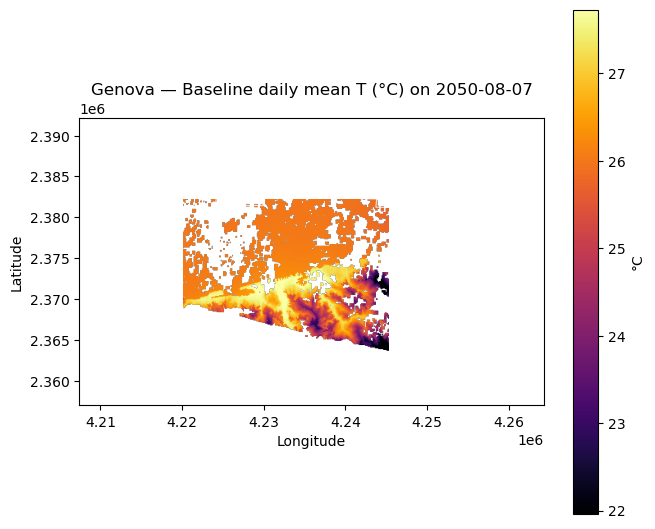

In [53]:
# plotting baseline
plt.figure(figsize=(6.8, 5.4))
im = plt.imshow(I_base_m, origin="upper", extent=extent, vmin=vmin, vmax=vmax, cmap="inferno")
if fua_ref is not None:
    fua_ref.boundary.plot(ax=plt.gca(), color="white", linewidth=0.8, alpha=0.8)
plt.title(f"{CITY} — Baseline daily mean T (°C) on {focus_date}")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
cb = plt.colorbar(im); cb.set_label("°C")
plt.tight_layout(); plt.show()

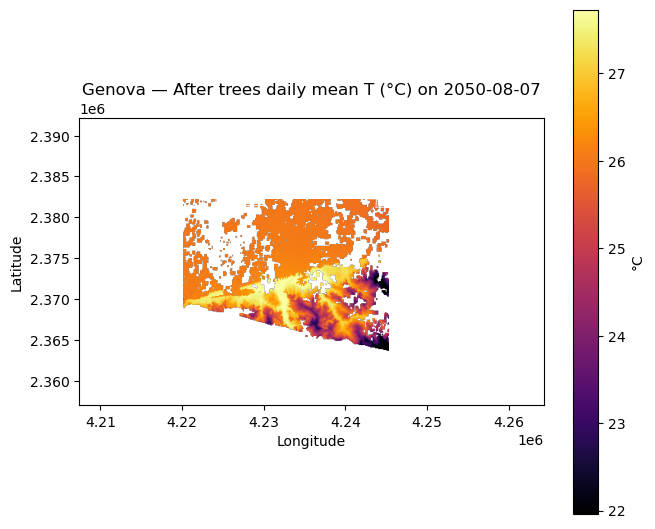

In [54]:
# plotting after-trees
plt.figure(figsize=(6.8, 5.4))
im = plt.imshow(I_tree_m, origin="upper", extent=extent, vmin=vmin, vmax=vmax, cmap="inferno")
if fua_ref is not None:
    fua_ref.boundary.plot(ax=plt.gca(), color="white", linewidth=0.8, alpha=0.8)
plt.title(f"{CITY} — After trees daily mean T (°C) on {focus_date}")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
cb = plt.colorbar(im); cb.set_label("°C")
plt.tight_layout(); plt.show()

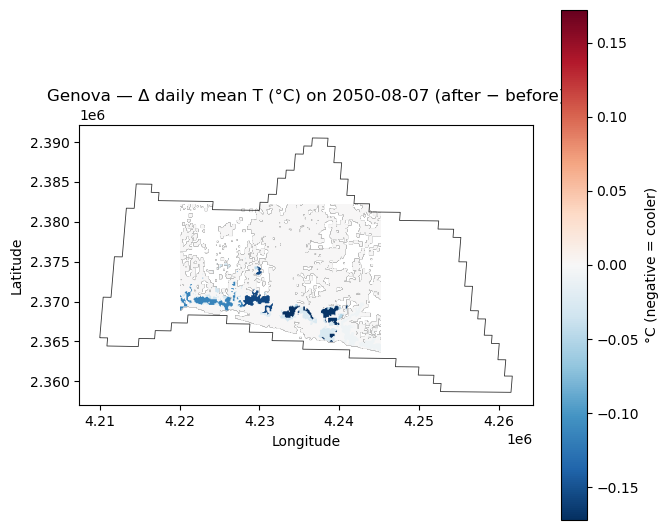

Genova 2050-08-07: city-mean baseline=25.96 °C, after-trees=25.95 °C, Δ=-0.010 °C


In [55]:
# Plot change (after − before)
plt.figure(figsize=(6.8, 5.4))
im = plt.imshow(D_m, origin="upper", extent=extent, norm=norm0, cmap="RdBu_r")
if fua_ref is not None:
    fua_ref.boundary.plot(ax=plt.gca(), color="black", linewidth=0.6, alpha=0.8)
plt.title(f"{CITY} — Δ daily mean T (°C) on {focus_date} (after − before)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
cb = plt.colorbar(im); cb.set_label("°C (negative = cooler)")
plt.tight_layout(); plt.show()

base_mean = float(np.nanmean(I_base_m))
tree_mean = float(np.nanmean(I_tree_m))
print(f"{CITY} {focus_date}: city-mean baseline={base_mean:.2f} °C, after-trees={tree_mean:.2f} °C, Δ={tree_mean - base_mean:+.3f} °C")

In [56]:
# Validation for daily T2M with AC: pixel sums and municipio breakdown (focus year)

import numpy as np, pandas as pd
from climada.entity.impact_funcs import ImpactFuncSet  

# helpers 
def _row_to_grid(mat, irow, shape):
    row = mat[irow, :]
    if hasattr(row, "toarray"):
        row = row.toarray()
    return np.asarray(row).ravel().reshape(shape)

def mdd_lookup(I, f):
    return np.interp(I, f.intensity, f.mdd, left=f.mdd[0], right=f.mdd[-1])

# making sure we have year_idx
if "year_idx" not in globals():
    dates = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))
    year_idx = dates.dt.year.to_numpy(int)

# focus year 
year_focus = int(((cfg or {}).get("trees", {}) or {}).get("focus_year", 2050))
assert (year_idx == year_focus).any(), f"No daily events for year {year_focus}"
rows_focus = np.where(year_idx == year_focus)[0]

# AC coverage for focus year (already built earlier from AC NPZ)
if "coverage_base_by_year" not in globals():
    raise RuntimeError("coverage_base_by_year is not defined; run the AC-baseline cell first.")
if year_focus not in coverage_base_by_year:
    raise KeyError(f"No AC coverage grid for focus year {year_focus} in coverage_base_by_year.")
cov_focus = coverage_base_by_year[year_focus].astype(float)

# per-day pixel totals over focus year, then sum 
Hh, Ww = ref_data.shape
CITY_PIX = CITY_MASK & (muni_on_ref >= 0)
OUT_PIX  = CITY_MASK & (muni_on_ref == 0)

city_day_base, city_day_trees = [], []

# per-pixel accumulators over the whole focus year (for municipio table)
deaths_base_pix  = np.zeros((Hh, Ww), dtype=float)
deaths_trees_pix = np.zeros((Hh, Ww), dtype=float)

for r in rows_focus:
    I_b = _row_to_grid(H.intensity,       r, (Hh, Ww))
    I_t = _row_to_grid(H_trees.intensity, r, (Hh, Ww))

    day_base  = np.zeros_like(I_b, dtype=float)
    day_trees = np.zeros_like(I_b, dtype=float)

    for age_lbl, f in age_ifs.items():
        pop_a = np.nan_to_num(age_on_ref[age_lbl], nan=0.0)

        # MDD from temperature
        mdd_b = mdd_lookup(I_b, f)
        mdd_t = mdd_lookup(I_t, f)

        # AC attenuation for this age (focus-year AC coverage, same for base and trees)
        eff_a = _eff_for_age(age_lbl, EFF_MAP, EFF_DEFAULT)
        mult  = np.clip(1.0 - eff_a * cov_focus, 0.0, 1.0)

        day_base  += pop_a * mdd_b * mult
        day_trees += pop_a * mdd_t * mult

    # keep city scope only
    day_base  = np.where(CITY_PIX, day_base,  0.0)
    day_trees = np.where(CITY_PIX, day_trees, 0.0)

    deaths_base_pix  += day_base
    deaths_trees_pix += day_trees

    city_day_base.append(float(np.nansum(day_base)))
    city_day_trees.append(float(np.nansum(day_trees)))

tot_base_pix  = float(np.sum(city_day_base))
tot_trees_pix = float(np.sum(city_day_trees))

# consistent per-100k denominator: city population (same as in AC annual tables)
pop_grid_focus = pop_on_ref_by_year[int(year_focus)]

den_exposure = float(np.nansum(pop_grid_focus[CITY_PIX]))
print(f"{CITY} {year_focus} — exposure denominator (city scope): {den_exposure:,.0f}")

print(
    f"[{year_focus}] AC-attenuated pixel totals — base:  {tot_base_pix:.2f} "
    f"({tot_base_pix/den_exposure*1e5:.2f} per 100k)"
)
print(
    f"[{year_focus}] AC-attenuated pixel totals — trees: {tot_trees_pix:.2f} "
    f"({tot_trees_pix/den_exposure*1e5:.2f} per 100k)"
)
print(
    f"[{year_focus}] AC-attenuated avoided deaths (city): "
    f"{(tot_base_pix - tot_trees_pix):.3f}"
)

# Municipio breakdown over the whole focus year (AC-aware) 
rows = []
M = muni_ok if 'muni_ok' in globals() else muni
for mid, name in zip(M["muni_id"], M["muni_name"]):
    m = CITY_MASK & (muni_on_ref == int(mid))
    if not np.any(m):
        continue
    pop_m = float(np.nansum(pop_grid_focus[m]))
    d_b   = float(np.nansum(deaths_base_pix[m]))
    d_t   = float(np.nansum(deaths_trees_pix[m]))
    d_avo = d_b - d_t
    rows.append({
        "muni_id": int(mid), "muni_name": name,
        "deaths_base": d_b, "deaths_tree": d_t, "deaths_avo": d_avo,
        "pop_m": pop_m,
        "avo_per_100k": (d_avo / pop_m * 1e5) if pop_m > 0 else np.nan,
        "delta_per_100k": ((d_t - d_b) / pop_m * 1e5) if pop_m > 0 else np.nan,  # trees − base
    })

# outside-bucket (ID 0 within FUA mask)
if OUT_PIX.any():
    pop_0 = float(np.nansum(pop_grid_focus[OUT_PIX]))
    d_b0  = float(np.nansum(deaths_base_pix[OUT_PIX]))
    d_t0  = float(np.nansum(deaths_trees_pix[OUT_PIX]))
    d_a0  = d_b0 - d_t0
    rows.append({
        "muni_id": 0, "muni_name": "Fuori Municipi (FUA)",
        "deaths_base": d_b0, "deaths_tree": d_t0, "deaths_avo": d_a0,
        "pop_m": pop_0,
        "avo_per_100k": (d_a0 / pop_0 * 1e5) if pop_0 > 0 else np.nan,
        "delta_per_100k": ((d_t0 - d_b0) / pop_0 * 1e5) if pop_0 > 0 else np.nan,
    })

benef_focus = (pd.DataFrame(rows)
               .sort_values("deaths_avo", ascending=False)
               .reset_index(drop=True))

# Totals row over CITY scope
city_avo_total = float(np.nansum((deaths_base_pix - deaths_trees_pix)[CITY_PIX]))
tot_row = pd.DataFrame([{
    "muni_id": 999,
    "muni_name": f"{CITY} — Totale (scope, AC-attenuated)",
    "deaths_base": float(np.nansum(deaths_base_pix[CITY_PIX])),
    "deaths_tree": float(np.nansum(deaths_trees_pix[CITY_PIX])),
    "deaths_avo":  city_avo_total,
    "pop_m": den_exposure,
    "avo_per_100k": (city_avo_total / den_exposure * 1e5) if den_exposure>0 else np.nan,
    "delta_per_100k": ((float(np.nansum((deaths_trees_pix - deaths_base_pix)[CITY_PIX])) / den_exposure * 1e5)
                       if den_exposure>0 else np.nan),
}])

benef_focus = pd.concat([benef_focus, tot_row], ignore_index=True)

tbl = benef_focus.copy()
tbl["avo_per_100k"] = (tbl["deaths_avo"] / tbl["pop_m"] * 1e5).where(tbl["pop_m"] > 0)

cols = ["muni_id","muni_name","pop_m",
        "deaths_base","deaths_tree","deaths_avo",
        "avo_per_100k","delta_per_100k"]
tbl = (tbl[[c for c in cols if c in tbl.columns]]
       .sort_values("deaths_avo", ascending=False)
       .reset_index(drop=True))

display(tbl.head(10))

# Cross-check municipio sum equals raster city total (exclude totals row)
sum_rows = float(benef_focus.loc[benef_focus["muni_id"] != 999, "deaths_avo"].sum())
print(f"{CITY} {year_focus} — avoided deaths with AC (raster city sum): {city_avo_total:.3f}")
print(f"{CITY} {year_focus} — avoided deaths with AC (sum of municipios): {sum_rows:.3f}")
assert np.isclose(city_avo_total, sum_rows, rtol=1e-6, atol=1e-3), "Municipio sum ≠ raster sum"

Genova 2050 — exposure denominator (city scope): 564,952
[2050] AC-attenuated pixel totals — base:  46.59 (8.25 per 100k)
[2050] AC-attenuated pixel totals — trees: 45.94 (8.13 per 100k)
[2050] AC-attenuated avoided deaths (city): 0.654


,muni_id,muni_name,pop_m,deaths_base,deaths_tree,deaths_avo,avo_per_100k,delta_per_100k
0,999,"Genova — Totale (scope, AC-attenuated)",564952.125000,46.592742,45.938777,0.653965,0.115756,-0.115756
1,7,Medio Ponente,69007.250000,7.397825,7.240470,0.157356,0.228028,-0.228028
2,8,Ponente,50792.390625,6.010743,5.863745,0.146999,0.289411,-0.289411
3,1,Bassa Val Bisagno,44982.246094,3.218351,3.087902,0.130448,0.290000,-0.290000
4,3,Centro Ovest,51726.390625,6.634590,6.530943,0.103646,0.200374,-0.200374
5,6,Medio Levante,68701.781250,3.413148,3.331994,0.081154,0.118125,-0.118125
6,2,Centro Est,66307.953125,1.536700,1.508485,0.028215,0.042552,-0.042552
7,4,Levante,65494.800781,2.562088,2.555941,0.006147,0.009385,-0.009385
8,5,Media Val Bisagno,53454.562500,4.512531,4.512531,0.000000,0.000000,0.000000
9,9,Val Polcevera,58699.257812,8.783330,8.783330,0.000000,0.000000,0.000000


Genova 2050 — avoided deaths with AC (raster city sum): 0.654
Genova 2050 — avoided deaths with AC (sum of municipios): 0.654


In [57]:
# Municipio population-weighted ΔT summaries (July and Jun–Sep): ITT and ETT
# ITT = include zeros (average effect over all residents in scope)
# ETT = exclude zeros (average effect where policy actually changes temps)

import numpy as np
import pandas as pd

def weighted_mean(values, weights):
    v = np.asarray(values, float).ravel()
    w = np.asarray(weights, float).ravel()
    m = np.isfinite(v) & np.isfinite(w) & (w > 0)
    return float(np.sum(v[m] * w[m]) / np.sum(w[m])) if m.any() else np.nan

# Scope:
# built LCZ 1–10
# inside city
# within policy (where change in GVI was defined)
built_mask = (lcz_on_ref >= 1) & (lcz_on_ref <= 10)
scope_mask = CITY_MASK & np.isfinite(dGVI_map_model)
M = muni_ok if 'muni_ok' in globals() else muni

pop_grid_focus = pop_on_ref_by_year[int(year_focus)]  # pick 2050 or from cfg

def muni_popw_table(field_2d, title_col, muni_frame, include_zeros: bool):
    finite = np.isfinite(field_2d)
    if include_zeros:
        base_mask = built_mask & scope_mask & finite           # ITT: keep zeros
        tag = "ITT"
    else:
        base_mask = built_mask & scope_mask & finite & (field_2d != 0)  # ETT: exclude zeros
        tag = "ETT"

    rows = []
    mids  = muni_frame["muni_id"].astype(int).values
    names = muni_frame["muni_name"].values

    ids = muni_on_ref.astype(int)
    for mid, name in zip(mids, names):
        m = (ids == int(mid)) & base_mask
        if not np.any(m):
            continue
        vals = field_2d[m].astype(float)
        w    = pop_grid_focus[m].astype(float)
        rows.append({
            "muni_id": int(mid),
            "muni_name": name,
            f"{title_col}_{tag}_popw_mean": weighted_mean(vals, w),
            f"{title_col}_{tag}_area_mean": float(np.nanmean(vals)),
            "pix": int(m.sum()),
            "pop_sum": float(np.nansum(w)),
            f"share_cooling_{tag}_popw": weighted_mean((vals < 0).astype(float), w),
        })

    out = pd.DataFrame(rows).sort_values(f"{title_col}_{tag}_popw_mean").reset_index(drop=True)

    # City line over same scope + same municipi set
    city_mask = np.isin(ids, mids) & base_mask
    if np.any(city_mask):
        vals_c = field_2d[city_mask].astype(float)
        w_c    = pop_on_ref[city_mask].astype(float)
        out = pd.concat([out, pd.DataFrame([{
            "muni_id": 999,
            "muni_name": f"{CITY} (built+policy, {tag})",
            f"{title_col}_{tag}_popw_mean": weighted_mean(vals_c, w_c),
            f"{title_col}_{tag}_area_mean": float(np.nanmean(vals_c)),
            "pix": int(city_mask.sum()),
            "pop_sum": float(np.nansum(w_c)),
            f"share_cooling_{tag}_popw": weighted_mean((vals_c < 0).astype(float), w_c),
        }])], ignore_index=True)

    return out

# Inputs: monthly change in T stack on the ref grid (12, H, W) 
# dT_month_ref is already cooling-only (negative) and zero outside built/policy scope.

# July
m = 7
dT_July = dT_month_ref[m-1]
df_jul_ITT = muni_popw_table(dT_July, "ΔT_Jul_degC", M, include_zeros=True)
df_jul_ETT = muni_popw_table(dT_July, "ΔT_Jul_degC", M, include_zeros=False)
display(df_jul_ITT); display(df_jul_ETT)

# Jun–Sep seasonal mean of ΔT
hot_months = [6, 7, 8, 9]
idx = [mm - 1 for mm in hot_months]
arr   = dT_month_ref[idx, :, :].astype(float)
count = np.sum(np.isfinite(arr), axis=0)
sum_  = np.nansum(arr, axis=0)
seasonal_mean = np.full_like(sum_, np.nan, dtype=float)
np.divide(sum_, count, out=seasonal_mean, where=(count > 0))

df_season_ITT = muni_popw_table(seasonal_mean, "ΔT_Season_degC", M, include_zeros=True)
df_season_ETT = muni_popw_table(seasonal_mean, "ΔT_Season_degC", M, include_zeros=False)
display(df_season_ITT); display(df_season_ETT)

,muni_id,muni_name,ΔT_Jul_degC_ITT_popw_mean,ΔT_Jul_degC_ITT_area_mean,pix,pop_sum,share_cooling_ITT_popw
0,1,Bassa Val Bisagno,-0.051269,-0.089602,497,43014.861615,0.413959
1,8,Ponente,-0.047247,-0.059056,1204,45396.182803,0.507228
2,3,Centro Ovest,-0.040424,-0.045360,679,50441.604408,0.337279
3,7,Medio Ponente,-0.033677,-0.062469,1151,64423.134757,0.288711
4,6,Medio Levante,-0.032892,-0.035017,577,68372.947071,0.648500
5,2,Centro Est,-0.023372,-0.030453,602,65202.400602,0.423401
6,4,Levante,-0.004916,-0.005033,1158,61778.280914,0.936032
7,5,Media Val Bisagno,0.000000,0.000000,1082,46334.956362,0.000000
8,9,Val Polcevera,0.000000,0.000000,1317,50220.061966,0.000000
9,999,"Genova (built+policy, ITT)",-0.025517,-0.031777,8267,505316.165185,0.416448


,muni_id,muni_name,ΔT_Jul_degC_ETT_popw_mean,ΔT_Jul_degC_ETT_area_mean,pix,pop_sum,share_cooling_ETT_popw
0,1,Bassa Val Bisagno,-0.123851,-0.137022,325,17806.371592,1.0
1,3,Centro Ovest,-0.119855,-0.143254,215,17012.884450,1.0
2,7,Medio Ponente,-0.116647,-0.136436,527,18599.646628,1.0
3,8,Ponente,-0.093147,-0.089213,797,23026.235749,1.0
4,2,Centro Est,-0.055201,-0.071058,258,27606.778222,1.0
5,6,Medio Levante,-0.050720,-0.054460,371,44339.831168,1.0
6,4,Levante,-0.005252,-0.005242,1112,57826.472704,1.0
7,999,"Genova (built+policy, ETT)",-0.061272,-0.072872,3605,210437.820127,1.0


,muni_id,muni_name,ΔT_Season_degC_ITT_popw_mean,ΔT_Season_degC_ITT_area_mean,pix,pop_sum,share_cooling_ITT_popw
0,1,Bassa Val Bisagno,-0.055069,-0.096273,497,43014.861615,0.413959
1,8,Ponente,-0.050751,-0.063465,1204,45396.182803,0.507228
2,3,Centro Ovest,-0.043408,-0.048716,679,50441.604408,0.337279
3,7,Medio Ponente,-0.036172,-0.067109,1151,64423.134757,0.288711
4,6,Medio Levante,-0.035281,-0.037578,577,68372.947071,0.648500
5,2,Centro Est,-0.025070,-0.032689,602,65202.400602,0.423401
6,4,Levante,-0.005280,-0.005409,1158,61778.280914,0.936032
7,5,Media Val Bisagno,0.000000,0.000000,1082,46334.956362,0.000000
8,9,Val Polcevera,0.000000,0.000000,1317,50220.061966,0.000000
9,999,"Genova (built+policy, ITT)",-0.027395,-0.034136,8267,505316.165185,0.416448


,muni_id,muni_name,ΔT_Season_degC_ETT_popw_mean,ΔT_Season_degC_ETT_area_mean,pix,pop_sum,share_cooling_ETT_popw
0,1,Bassa Val Bisagno,-0.133031,-0.147223,325,17806.371592,1.0
1,3,Centro Ovest,-0.128702,-0.153852,215,17012.884450,1.0
2,7,Medio Ponente,-0.125289,-0.146571,527,18599.646628,1.0
3,8,Ponente,-0.100056,-0.095874,797,23026.235749,1.0
4,2,Centro Est,-0.059212,-0.076275,258,27606.778222,1.0
5,6,Medio Levante,-0.054404,-0.058443,371,44339.831168,1.0
6,4,Levante,-0.005641,-0.005633,1112,57826.472704,1.0
7,999,"Genova (built+policy, ETT)",-0.065784,-0.078282,3605,210437.820127,1.0


> **Interpretation:**
> - Exclude zeros (no Δ=0): “How much cooling did the policy produce where it acted?”. Kind of Effect on treated.
> - Include zeros: “What’s the average cooling for residents of the policy area overall?”. Kind of Intent-to-treat (include zeros) => show the population-average effect.

**Saving for later**

In [58]:
from pathlib import Path
import json, numpy as np, pandas as pd
import rasterio as rio

OUT = Path(OUT); INT = Path(INT)
OUT.mkdir(parents=True, exist_ok=True); INT.mkdir(parents=True, exist_ok=True)

def _write_tif(path, arr, ref_meta, nodata=np.nan, dtype="float32"):
    meta = ref_meta.copy()
    meta.update(dtype=dtype, nodata=nodata, compress="LZW")
    with rio.open(path, "w", **meta) as dst:
        dst.write(arr.astype(dtype), 1)

def _write_events_csv(H, path, name_prefix="T2M"):
    df = pd.DataFrame({
        "row": np.arange(H.intensity.shape[0], dtype=int),
        "event_id": H.event_id.astype(int),
        "date": pd.to_datetime(H.date).astype(str),
        "event_name": [f"{name_prefix}_{pd.to_datetime(d).date()}" for d in H.date],
        "frequency": getattr(H, "frequency", np.ones(len(H.event_id), float)),
    })
    df.to_csv(path, index=False)
    return path

# vectors + rasters
gpkg_path = OUT / f"{SLUG}_regions.gpkg"
if gpkg_path.exists(): gpkg_path.unlink()
regions.to_file(gpkg_path, layer="regions", driver="GPKG")
muni.to_file(gpkg_path,    layer="muni",    driver="GPKG")

lut = (regions[["muni_id","muni_name"]]
       .drop_duplicates().assign(muni_id=lambda d: d["muni_id"].astype(int))
       .sort_values("muni_id"))
lut_csv = OUT / f"{SLUG}_muni_lut.csv"
lut.to_csv(lut_csv, index=False)

muni_tif = OUT / f"{SLUG}_muni_on_ref.tif"
_write_tif(muni_tif, np.where(CITY_MASK, muni_on_ref, 0), ref_meta, nodata=0, dtype="int32")

# hazards: baseline exists, write after-trees + events CSVs
H_BASE_H5  = INT / f"hazard_T2M_daily_{SLUG}.h5"
EVT_BASE   = INT / f"hazard_T2M_daily_events_{SLUG}.csv"
_ = _write_events_csv(H, EVT_BASE, name_prefix="T2M")

H_TREES_H5 = INT / f"hazard_T2M_daily_trees_{SLUG}.h5"
H_trees.haz_type = "T2M"; H_trees.units = "degC (daily mean)"
H_trees.write_hdf5(H_TREES_H5)
EVT_TREES  = INT / f"hazard_T2M_daily_events_trees_{SLUG}.csv"
_ = _write_events_csv(H_trees, EVT_TREES, name_prefix="T2M")

# AUX bundle
AUX_NPZ = INT / f"{SLUG}_veg_aux_arrays.npz"
np.savez_compressed(
    AUX_NPZ,
    CITY_MASK=CITY_MASK.astype("bool"),
    HAZ_MASK=HAZ_MASK.astype("bool"),
    muni_on_ref=muni_on_ref.astype("int32"),
    lcz_on_ref=lcz_on_ref.astype("int16"),
    pop_on_ref=pop_on_ref.astype("float32"),
    age_lt15=age_on_ref["<15"].astype("float32"),
    age_15_64=age_on_ref["15-64"].astype("float32"),
    age_65p=age_on_ref["65+"].astype("float32"),
    gvi_on_ref=gvi_on_ref.astype("float32"),          # 0–1
    dGVI_points=dGVI_points.astype("float32"),        # 0–100, zeros outside POLICY
    dT_month_ref=dT_month_ref.astype("float32"),      # (12,H,W), °C
)

# policy tables
TAB_DIR = OUT / "tables"; TAB_DIR.mkdir(exist_ok=True)
reg_gvi.to_csv(      TAB_DIR / f"{SLUG}_reg_gvi_descriptive.csv", index=False)
reg_gvi_ok.to_csv(   TAB_DIR / f"{SLUG}_reg_gvi_baseline_kept.csv", index=False)
reg_gvi_grid.to_csv( TAB_DIR / f"{SLUG}_reg_gvi_popw_grid.csv", index=False)
trees_tbl.to_csv(    TAB_DIR / f"{SLUG}_trees_tbl.csv", index=False)
df_jul_ITT.to_csv(   TAB_DIR / f"{SLUG}_ΔT_July_degC_ITT.csv", index=False)
df_jul_ETT.to_csv(   TAB_DIR / f"{SLUG}_ΔT_July_degC_ETT.csv", index=False)
df_season_ITT.to_csv(TAB_DIR / f"{SLUG}_ΔT_Season_degC_ITT.csv", index=False)
df_season_ETT.to_csv(TAB_DIR / f"{SLUG}_ΔT_Season_degC_ETT.csv", index=False)

2025-12-09 18:37:16,101 - climada.hazard.io - WARNING - write_hdf5: the class member date is skipped, due to its type, ndarray, for which writing to hdf5 is not implemented. Reading this H5 file will probably lead to date being set to its default value.


Careful: what I'm doing and not doing here:
- For impacts (deaths, rates, avoided deaths): now the hazard and the matching year’s population/AC coverage (so now the pop changes over time, not stucked anymore on the 2030 pop).
- For the tree policy itself (where trees go, ΔGVI per municipio/pixel): No, that part is fixed to 2030. Aplying the same tree plan across future years, which is consistent if the interpretation is “we design the plan in 2030 and then see its effects over time” => If we want the tree allocation to adapt to 2040 / 2050 demographics, we would have to redo the GVI + pop-weighted targeting parts with age_on_ref_by_year[y] / pop_on_ref_by_year[y] for each year. 